# Advanced Semiconductor Supply Chain — Data Analysis
### AISI Project | Dataset 1 of 5

This notebook loads, combines, cleans, and explores the **ETO Advanced Semiconductor Supply Chain Dataset**, which maps the tools, materials, processes, countries, and firms involved in producing advanced logic chips.

**Five source tables:** `inputs`, `providers`, `provision`, `sequence`, `stages`

---

## 1. Setup & Data Loading

In [2]:
!pip install pandas numpy matplotlib seaborn jupyter nbformat openpyxl scikit-learn networkx plotly kaleido squarify

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style Configuration ──
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor': '#0D1117',
    'text.color': '#C9D1D9',
    'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E',
    'ytick.color': '#8B949E',
    'axes.edgecolor': '#21262D',
    'grid.color': '#21262D',
    'grid.alpha': 0.6,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
    'figure.dpi': 120,
})

# Custom color palette
COLORS = {
    'accent':    '#58A6FF',
    'accent2':   '#3FB950',
    'accent3':   '#D29922',
    'accent4':   '#F778BA',
    'accent5':   '#BC8CFF',
    'danger':    '#F85149',
    'muted':     '#484F58',
    'bg':        '#0D1117',
    'surface':   '#161B22',
    'border':    '#21262D',
    'text':      '#C9D1D9',
    'text_dim':  '#8B949E',
}
PALETTE = [COLORS['accent'], COLORS['accent2'], COLORS['accent3'], 
           COLORS['accent4'], COLORS['accent5'], COLORS['danger']]

print('Setup complete ✓')

Setup complete ✓


In [4]:
# ── Load all 5 CSV files ──
DATA_DIR = '/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/'

inputs    = pd.read_csv(f'{DATA_DIR}inputs.csv')
providers = pd.read_csv(f'{DATA_DIR}providers.csv')
provision = pd.read_csv(f'{DATA_DIR}provision.csv')
sequence  = pd.read_csv(f'{DATA_DIR}sequence.csv')
stages    = pd.read_csv(f'{DATA_DIR}stages.csv')

print('Loaded 5 tables:')
for name, df in [('inputs', inputs), ('providers', providers), 
                  ('provision', provision), ('sequence', sequence), ('stages', stages)]:
    print(f'  {name:12s} → {df.shape[0]:>5,} rows × {df.shape[1]:>2} cols')

Loaded 5 tables:
  inputs       →   126 rows × 10 cols
  providers    →   397 rows ×  5 cols
  provision    → 1,305 rows ×  7 cols
  sequence     →   139 rows ×  6 cols
  stages       →     3 rows ×  6 cols


---
## 2. Individual Table Inspection

Before combining, let's understand each table's structure, data quality, and key distributions.

### 2.1 Inputs Table
Core catalog of 126 inputs to chip production: tools, materials, processes, and designs.

In [5]:
print('Shape:', inputs.shape)
print('\nColumns & types:')
print(inputs.dtypes.to_string())
print('\nMissing values:')
print(inputs.isnull().sum()[inputs.isnull().sum() > 0].to_string())
print('\nInput types:')
print(inputs['type'].value_counts().to_string())
print('\nData years:')
print(inputs['year'].value_counts().sort_index().to_string())
inputs.head(3)

Shape: (126, 10)

Columns & types:
input_id                                       object
input_name                                     object
type                                           object
stage_name                                     object
stage_id                                       object
description                                    object
year                                          float64
market_share_chart_global_market_size_info     object
market_share_chart_caption                    float64
market_share_chart_source                      object

Missing values:
stage_name                                    115
stage_id                                      115
year                                           22
market_share_chart_global_market_size_info     23
market_share_chart_caption                    126
market_share_chart_source                      23

Input types:
type
tool_resource        90
material_resource    17
process              11
design_resource  

,input_id,input_name,type,stage_name,stage_id,description,year,market_share_chart_global_market_size_info,market_share_chart_caption,market_share_chart_source
0,N0,Chip design,process,Design,S1,"Chip design involves specification, logic desi...",2022.0,$574.1 billion (2022),NaN,Worldwide semiconductor sales. [World Semicond...
1,N6,Logic chip design,design_resource,NaN,NaN,Logic chip design is the design of integrated ...,2022.0,$255.7 billion (2022),NaN,Worldwide semiconductor sales for logic and mi...
2,N1,Advanced CPUs,design_resource,NaN,NaN,"Central processing units (""CPUs"") are the domi...",2019.0,$56.2 billion (microprocessors) (2019),NaN,[CSET](https://cset.georgetown.edu/publication...


### 2.2 Providers Table
Countries and firms that supply inputs. A provider may appear multiple times (aliases).

In [6]:
print('Shape:', providers.shape)
print('\nProvider types:')
print(providers['provider_type'].value_counts().to_string())

# Unique providers (deduplicate aliases)
unique_providers = providers.drop_duplicates(subset='provider_id')
print(f'\nUnique providers: {len(unique_providers)}')
print(f'  Countries: {len(unique_providers[unique_providers.provider_type=="country"])}')
print(f'  Organizations: {len(unique_providers[unique_providers.provider_type=="organization"])}')

# Top countries by org count
orgs = unique_providers[unique_providers['provider_type'] == 'organization']
print(f'\nOrganizations by HQ country (top 15):')
print(orgs['country'].value_counts().head(15).to_string())
print(f'\nMissing country (for orgs): {orgs["country"].isna().sum()}')

Shape: (397, 5)

Provider types:
provider_type
organization    374
country          23

Unique providers: 393
  Countries: 23
  Organizations: 370

Organizations by HQ country (top 15):
country
CHN    93
USA    80
JPN    73
KOR    42
TWN    20
DEU    19
SGP     7
GBR     6
NLD     5
FRA     5
ITA     4
CHE     3
ISR     2
MYS     2
AUT     2

Missing country (for orgs): 0


### 2.3 Provision Table
The core linkage: which providers supply which inputs, with market share percentages.

In [7]:
print('Shape:', provision.shape)
print('\nMissing values:')
print(provision.isnull().sum().to_string())
print(f'\nMarket share coverage: {provision.share_provided.notna().sum()}/{len(provision)} '
      f'({provision.share_provided.notna().mean():.1%})')
print('\nMarket share distribution (where available):')
print(provision['share_provided'].describe().to_string())
print('\nData years:')
print(provision['year'].value_counts().sort_index().to_string())
provision.head(3)

Shape: (1305, 7)

Missing values:
provider_name       0
provider_id         0
provided_name       8
provided_id         0
share_provided    254
year                0
source            135

Market share coverage: 1051/1305 (80.5%)

Market share distribution (where available):
count    1051.000000
mean       17.320647
std        25.274245
min         0.000000
25%         1.500000
50%         5.200000
75%        20.500000
max       100.000000

Data years:
year
2019    272
2022     43
2024    990


,provider_name,provider_id,provided_name,provided_id,share_provided,year,source
0,ACM Research,P313,Wet etching and cleaning tools,N49,11.4,2024,CSET analysis of TechInsights data (2024). Dat...
1,ACM Research,P313,Etch and clean tools,N55,3.0,2024,CSET analysis of TechInsights data (2024). Dat...
2,AMEC,P123,Dry etching tools (adv. pkg.),N101,18.1,2024,CSET analysis of TechInsights data (2024). Dat...


### 2.4 Sequence Table
Relationships between inputs: 'goes into' (supply chain flow) and 'is type of' (taxonomy).

In [8]:
print('Shape:', sequence.shape)
goes_into = sequence[sequence['goes_into_id'].notna()]
is_type_of = sequence[sequence['is_type_of_id'].notna()]
print(f'\nRelationship types:')
print(f'  "goes into":   {len(goes_into)} (supply chain flow)')
print(f'  "is type of":  {len(is_type_of)} (taxonomy/subtypes)')
print(f'\nSample "goes into" relationships:')
print(goes_into[['input_name', 'goes_into_name']].head(5).to_string(index=False))
print(f'\nSample "is type of" relationships:')
print(is_type_of[['input_name', 'is_type_of_name']].head(5).to_string(index=False))

Shape: (139, 6)

Relationship types:
  "goes into":   53 (supply chain flow)
  "is type of":  86 (taxonomy/subtypes)

Sample "goes into" relationships:
              input_name                    goes_into_name
Crystal growing furnaces                             Wafer
 Crystal machining tools                             Wafer
       Lithography tools                  Photolithography
        Ion implantation Chemical mechanical planarization
          Etch and clean                  Ion implantation

Sample "is type of" relationships:
                           input_name            is_type_of_name
                EUV lithography tools          Lithography tools
      ArF dry (DUV) lithography tools          Lithography tools
ArF immersion (DUV) lithography tools          Lithography tools
           Maskless lithography tools          Lithography tools
       Mask exposure systems - e-beam Maskless lithography tools


### 2.5 Stages Table
The three high-level production stages.

In [9]:
print('Shape:', stages.shape)
print()
for _, row in stages.iterrows():
    print(f'{row.stage_id}: {row.stage_name}')
    print(f'   Market size: {row.market_share_chart_global_market_size_info}')
    print()

Shape: (3, 6)

S1: Design
   Market size: $574 billion (2022)

S2: Fabrication
   Market size: nan

S3: Assembly, testing, and packaging (ATP)
   Market size: $95 billion (2022)



---
## 3. Combining Tables Into a Master Dataset

The core analytical unit is the **provision** table (provider–input pairs with market shares). We'll enrich it by joining in metadata from all other tables to create a single, analysis-ready master dataset.

In [10]:
# ── Step 1: Deduplicate providers (drop alias rows, keep one row per provider_id) ──
providers_dedup = providers.drop_duplicates(subset='provider_id').copy()
providers_dedup = providers_dedup.rename(columns={'country': 'provider_hq_country'})
print(f'Providers: {len(providers)} rows → {len(providers_dedup)} unique providers')

Providers: 397 rows → 393 unique providers


In [11]:
# ── Step 2: Join provision with provider metadata ──
master = provision.merge(
    providers_dedup[['provider_id', 'provider_type', 'provider_hq_country']],
    on='provider_id',
    how='left'
)
print(f'After provider join: {master.shape}')
print(f'Provider types in master: {master.provider_type.value_counts().to_dict()}')

After provider join: (1305, 9)
Provider types in master: {'organization': 723, 'country': 582}


In [12]:
# ── Step 3: Join with input metadata ──
inputs_meta = inputs[['input_id', 'input_name', 'type', 'stage_name', 'stage_id',
                       'year', 'market_share_chart_global_market_size_info']].copy()
inputs_meta = inputs_meta.rename(columns={
    'input_name': 'input_name_full',
    'type': 'input_type',
    'year': 'input_data_year',
    'market_share_chart_global_market_size_info': 'input_market_size'
})

master = master.merge(
    inputs_meta,
    left_on='provided_id',
    right_on='input_id',
    how='left'
)
print(f'After input join: {master.shape}')

After input join: (1305, 16)


In [13]:
# ── Step 4: Join with stage metadata ──
stages_meta = stages[['stage_id', 'stage_name']].copy()
stages_meta = stages_meta.rename(columns={'stage_name': 'production_stage'})

# For process-type inputs, stage comes from the inputs table
# For non-process inputs, we can trace through sequence → process → stage
# For now, use the direct stage_id from inputs
master = master.merge(
    stages_meta,
    on='stage_id',
    how='left'
)
print(f'After stage join: {master.shape}')
print(f'\nProduction stages mapped: {master.production_stage.value_counts().to_dict()}')
print(f'Unmapped to stage: {master.production_stage.isna().sum()}')

After stage join: (1305, 17)

Production stages mapped: {'Design': 7}
Unmapped to stage: 1298


In [14]:
# ── Step 5: Derive country-level market share for organizations ──
# For organization providers, add the country they belong to
# For country providers, use the provider_name (ISO code) as the country
master['effective_country'] = np.where(
    master['provider_type'] == 'country',
    master['provider_name'],
    master['provider_hq_country']
)

print('Effective country coverage:')
print(f'  Filled: {master.effective_country.notna().sum()}')
print(f'  Missing: {master.effective_country.isna().sum()}')
print(f'  Unique countries: {master.effective_country.nunique()}')

Effective country coverage:
  Filled: 1305
  Missing: 0
  Unique countries: 21


In [15]:
# ── Step 6: Final cleanup ──
# Drop redundant columns
master = master.drop(columns=['input_id'], errors='ignore')

# Rename for clarity
master = master.rename(columns={
    'provided_name': 'input_name',
    'provided_id': 'input_id',
    'year': 'provision_year',
})

# Reorder columns
col_order = [
    'provider_name', 'provider_id', 'provider_type', 'provider_hq_country', 'effective_country',
    'input_name', 'input_id', 'input_name_full', 'input_type',
    'production_stage', 'stage_id', 'input_data_year',
    'share_provided', 'provision_year',
    'input_market_size', 'source'
]
master = master[[c for c in col_order if c in master.columns]]

print(f'✅ Master dataset: {master.shape[0]:,} rows × {master.shape[1]} columns')
print(f'\nColumn summary:')
for col in master.columns:
    non_null = master[col].notna().sum()
    pct = non_null / len(master) * 100
    print(f'  {col:30s}  {non_null:>5,} / {len(master):,}  ({pct:5.1f}%)')

✅ Master dataset: 1,305 rows × 16 columns

Column summary:
  provider_name                   1,305 / 1,305  (100.0%)
  provider_id                     1,305 / 1,305  (100.0%)
  provider_type                   1,305 / 1,305  (100.0%)
  provider_hq_country               728 / 1,305  ( 55.8%)
  effective_country               1,305 / 1,305  (100.0%)
  input_name                      1,297 / 1,305  ( 99.4%)
  input_id                        1,305 / 1,305  (100.0%)
  input_name_full                 1,276 / 1,305  ( 97.8%)
  input_type                      1,276 / 1,305  ( 97.8%)
  production_stage                    7 / 1,305  (  0.5%)
  stage_id                            7 / 1,305  (  0.5%)
  input_data_year                 1,170 / 1,305  ( 89.7%)
  share_provided                  1,051 / 1,305  ( 80.5%)
  provision_year                  1,305 / 1,305  (100.0%)
  input_market_size               1,170 / 1,305  ( 89.7%)
  source                          1,170 / 1,305  ( 89.7%)


In [16]:
master.head(10)

,provider_name,provider_id,provider_type,provider_hq_country,effective_country,input_name,input_id,input_name_full,input_type,production_stage,stage_id,input_data_year,share_provided,provision_year,input_market_size,source
0,ACM Research,P313,organization,USA,USA,Wet etching and cleaning tools,N49,Wet etching and cleaning tools,tool_resource,NaN,NaN,2024.0,11.4,2024,$6.4 billion (2024),CSET analysis of TechInsights data (2024). Dat...
1,ACM Research,P313,organization,USA,USA,Etch and clean tools,N55,Etch and clean tools,tool_resource,NaN,NaN,2024.0,3.0,2024,$24.7 billion (2024),CSET analysis of TechInsights data (2024). Dat...
2,AMEC,P123,organization,CHN,CHN,Dry etching tools (adv. pkg.),N101,Dry etching tools (adv. pkg.),tool_resource,NaN,NaN,2024.0,18.1,2024,$831.6 million (2024),CSET analysis of TechInsights data (2024). Dat...
3,AMEC,P123,organization,CHN,CHN,Dry etch tools,N103,Dry etch tools,tool_resource,NaN,NaN,2024.0,5.5,2024,$18.5 billion (2024),CSET analysis of TechInsights data (2024). Dat...
4,AMEC,P123,organization,CHN,CHN,Fabrication tools (for advanced packaging),N109,Fabrication tools (for advanced packaging),tool_resource,NaN,NaN,2024.0,2.5,2024,$5.9 billion (2024),CSET analysis of TechInsights data (2024). Dat...
5,AMEC,P123,organization,CHN,CHN,Etch and clean tools (adv. pkg.),N129,Etch and clean tools (adv. pkg.),tool_resource,NaN,NaN,2024.0,12.2,2024,$1.2 billion (2024),CSET analysis of TechInsights data (2024). Dat...
6,AMEC,P123,organization,CHN,CHN,Low-pressure CVD tools,N39,Low-pressure CVD tools,tool_resource,NaN,NaN,2024.0,1.2,2024,$1.8 billion (2024),CSET analysis of TechInsights data (2024). Dat...
7,AMEC,P123,organization,CHN,CHN,Dry etching and cleaning tools,N48,Dry etching and cleaning tools,tool_resource,NaN,NaN,2024.0,5.3,2024,$19.1 billion (2024),CSET analysis of TechInsights data (2024). Dat...
8,AMEC,P123,organization,CHN,CHN,Conductor etching tools,N50,Conductor etching tools,tool_resource,NaN,NaN,2024.0,1.4,2024,$9.9 billion (2024),CSET analysis of TechInsights data (2024). Dat...
9,AMEC,P123,organization,CHN,CHN,Insulator etching tools,N51,Insulator etching tools,tool_resource,NaN,NaN,2024.0,9.7,2024,$7.4 billion (2024),CSET analysis of TechInsights data (2024). Dat...


---
## 4. Data Cleaning & Quality Assessment

In [17]:
# ── 4.1 Check for duplicate provision rows ──
dupes = master.duplicated(subset=['provider_id', 'input_id'], keep=False)
print(f'Duplicate provider-input pairs: {dupes.sum()}')
if dupes.sum() > 0:
    print(master[dupes].sort_values(['provider_id', 'input_id']).head(10))

Duplicate provider-input pairs: 0


In [18]:
# ── 4.2 Validate market shares per input ──
# For each input, country-level shares should roughly sum to ~100%
country_provisions = master[master['provider_type'] == 'country'].copy()
share_sums = country_provisions.groupby('input_id')['share_provided'].sum().dropna()

print('Market share sums per input (country-level):')
print(f'  Mean:   {share_sums.mean():.1f}%')
print(f'  Median: {share_sums.median():.1f}%')
print(f'  Min:    {share_sums.min():.1f}%')
print(f'  Max:    {share_sums.max():.1f}%')

outliers = share_sums[(share_sums < 90) | (share_sums > 110)]
print(f'\nInputs with share sums outside 90-110%: {len(outliers)}')
if len(outliers) > 0:
    print(outliers.head(10))

Market share sums per input (country-level):
  Mean:   84.2%
  Median: 100.0%
  Min:    0.0%
  Max:    102.0%

Inputs with share sums outside 90-110%: 18
input_id
N1      0.0
N100    0.0
N2      0.0
N3      0.0
N31     0.0
N4      0.0
N61     0.0
N68     0.0
N88     0.0
N90     0.0
Name: share_provided, dtype: float64


In [19]:
# ── 4.3 Check "Various countries" and "Various companies" entries ──
various = master[master['provider_name'].str.contains('Various', case=False, na=False)]
print(f'"Various" entries: {len(various)}')
print(various['provider_name'].value_counts().to_string())
print(f'\nThese represent aggregated small providers (<1% share each)')

"Various" entries: 133
provider_name
Various companies    70
Various countries    62
Various               1

These represent aggregated small providers (<1% share each)


In [20]:
# ── 4.4 Identify inputs with no market share data ──
inputs_with_shares = master[master['share_provided'].notna()]['input_id'].unique()
all_input_ids = master['input_id'].unique()
no_share_inputs = set(all_input_ids) - set(inputs_with_shares)
print(f'Inputs with market share data: {len(inputs_with_shares)}')
print(f'Inputs without market share data: {len(no_share_inputs)}')
if no_share_inputs:
    missing_df = master[master['input_id'].isin(no_share_inputs)][['input_id', 'input_name']].drop_duplicates()
    print('\nInputs missing shares:')
    print(missing_df.to_string(index=False))

Inputs with market share data: 96
Inputs without market share data: 18

Inputs missing shares:
input_id             input_name
     N96             Substrates
      N1          Advanced CPUs
      N3                  FPGAs
      N2          Discrete GPUs
     N93            Lead frames
     N91       Electronic gases
     N95       Ceramic packages
     N90          CMP materials
     N92          Wet chemicals
      N4               AI ASICs
     N31           Photoresists
     N88   Deposition materials
     N94             Bond wires
     N97   Encapsulation resins
     N98   Die attach materials
     N61 Wafer inspection tools
    N100    Packaging materials
     N68                    NaN


In [21]:
# ── 4.5 Data year consistency ──
print('Provision data years vs input data years:')
year_comparison = master.groupby('input_id').agg(
    provision_year=('provision_year', 'first'),
    input_data_year=('input_data_year', 'first'),
    input_name=('input_name', 'first')
).dropna(subset=['input_data_year'])

mismatched = year_comparison[year_comparison['provision_year'] != year_comparison['input_data_year']]
print(f'Inputs with matching years: {len(year_comparison) - len(mismatched)}')
print(f'Inputs with mismatched years: {len(mismatched)}')
if len(mismatched) > 0:
    print(mismatched.head(10))

Provision data years vs input data years:
Inputs with matching years: 100
Inputs with mismatched years: 0


---
## 5. Save Combined & Cleaned Dataset

In [22]:
# Save master dataset
output_path = '/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_master.csv'
master.to_csv(output_path, index=False)
print(f'✅ Saved: {output_path}')
print(f'   Shape: {master.shape[0]:,} rows × {master.shape[1]} columns')

# Also save the sequence table separately (it's a graph, not tabular join)
seq_path = '/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_sequence.csv'
sequence.to_csv(seq_path, index=False)
print(f'✅ Saved: {seq_path}')
print(f'   Shape: {sequence.shape[0]:,} rows × {sequence.shape[1]} columns')

✅ Saved: /Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_master.csv
   Shape: 1,305 rows × 16 columns
✅ Saved: /Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_sequence.csv
   Shape: 139 rows × 6 columns


---
## 6. Exploratory Analysis & Visualizations

Now let's dig into the data with clean, informative visualizations.

### 6.1 Dataset Overview

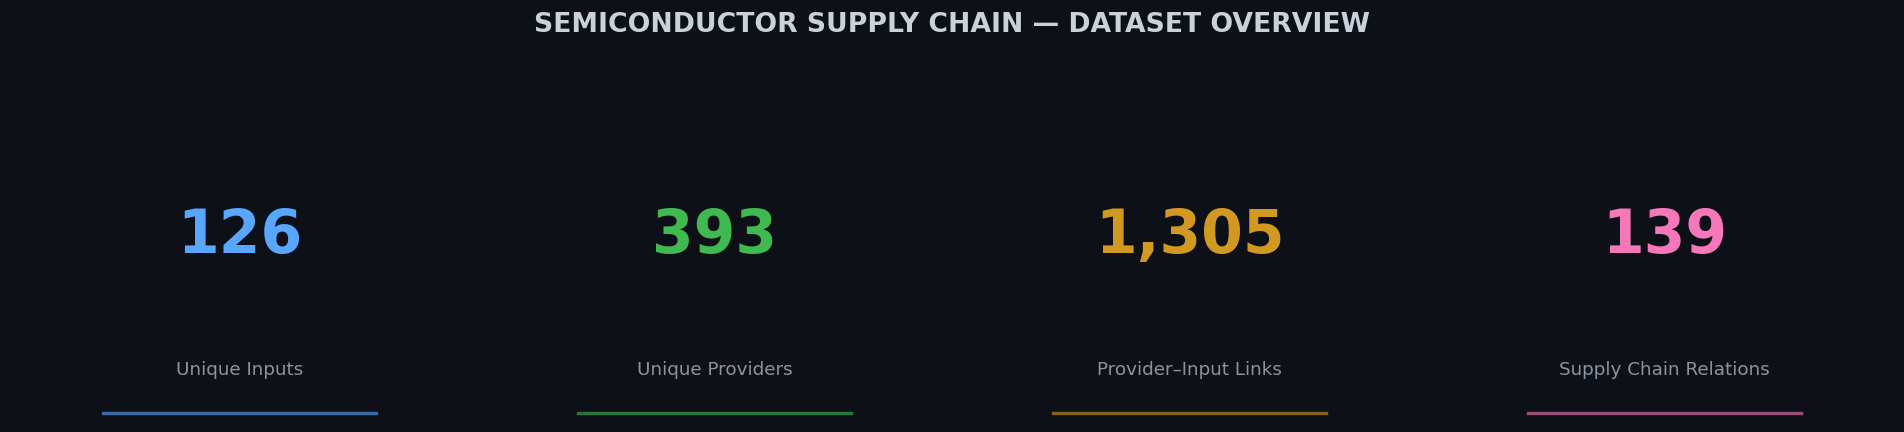

In [23]:
# ── Overview summary card ──
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle('SEMICONDUCTOR SUPPLY CHAIN — DATASET OVERVIEW', 
             fontsize=16, fontweight='bold', color=COLORS['text'], y=1.02)

stats = [
    ('Unique Inputs', inputs.shape[0], COLORS['accent']),
    ('Unique Providers', providers.drop_duplicates('provider_id').shape[0], COLORS['accent2']),
    ('Provider–Input Links', provision.shape[0], COLORS['accent3']),
    ('Supply Chain Relations', sequence.shape[0], COLORS['accent4']),
]

for ax, (label, value, color) in zip(axes, stats):
    ax.text(0.5, 0.55, f'{value:,}', fontsize=36, fontweight='bold', 
            color=color, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 0.15, label, fontsize=11, color=COLORS['text_dim'],
            ha='center', va='center', transform=ax.transAxes)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    # Subtle bottom accent line
    ax.axhline(y=0.02, xmin=0.2, xmax=0.8, color=color, linewidth=2, alpha=0.6)

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_01_overview.png', bbox_inches='tight', 
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.2 Input Types Distribution

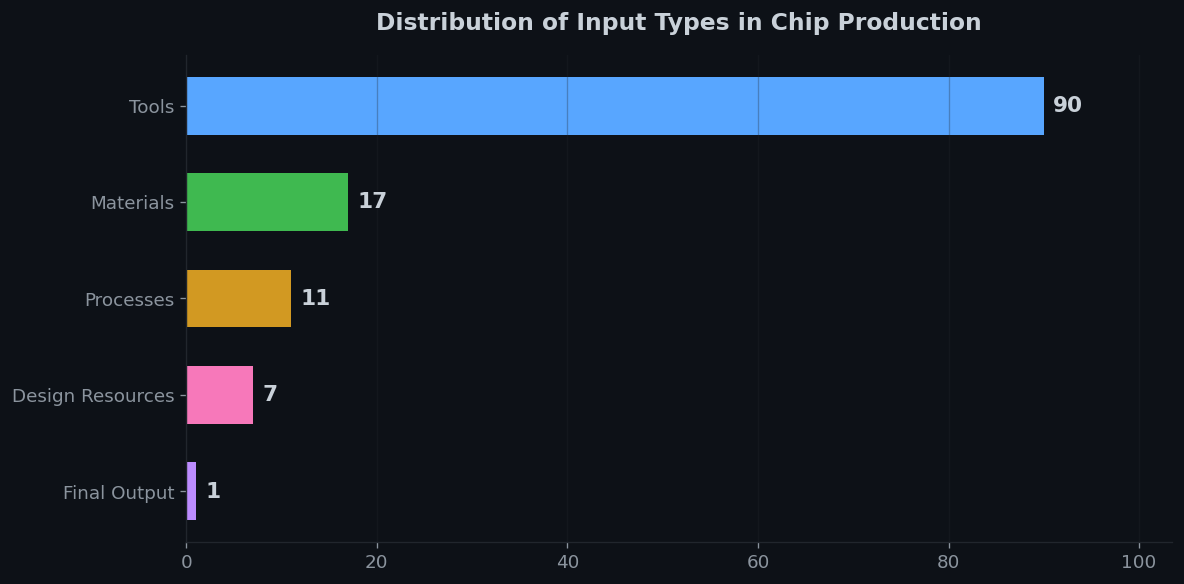

In [24]:
# ── Input type breakdown ──
type_counts = inputs['type'].value_counts()
type_labels = {
    'tool_resource': 'Tools',
    'material_resource': 'Materials',
    'process': 'Processes',
    'design_resource': 'Design Resources',
    'ultimate_output': 'Final Output'
}

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    [type_labels.get(t, t) for t in type_counts.index],
    type_counts.values,
    color=[COLORS['accent'], COLORS['accent2'], COLORS['accent3'], 
           COLORS['accent4'], COLORS['accent5']][:len(type_counts)],
    height=0.6,
    edgecolor='none'
)

for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=13, fontweight='bold', color=COLORS['text'])

ax.set_xlabel('')
ax.set_title('Distribution of Input Types in Chip Production', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, type_counts.max() * 1.15)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_02_input_types.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.3 Country Dominance — Organization Count by HQ Country

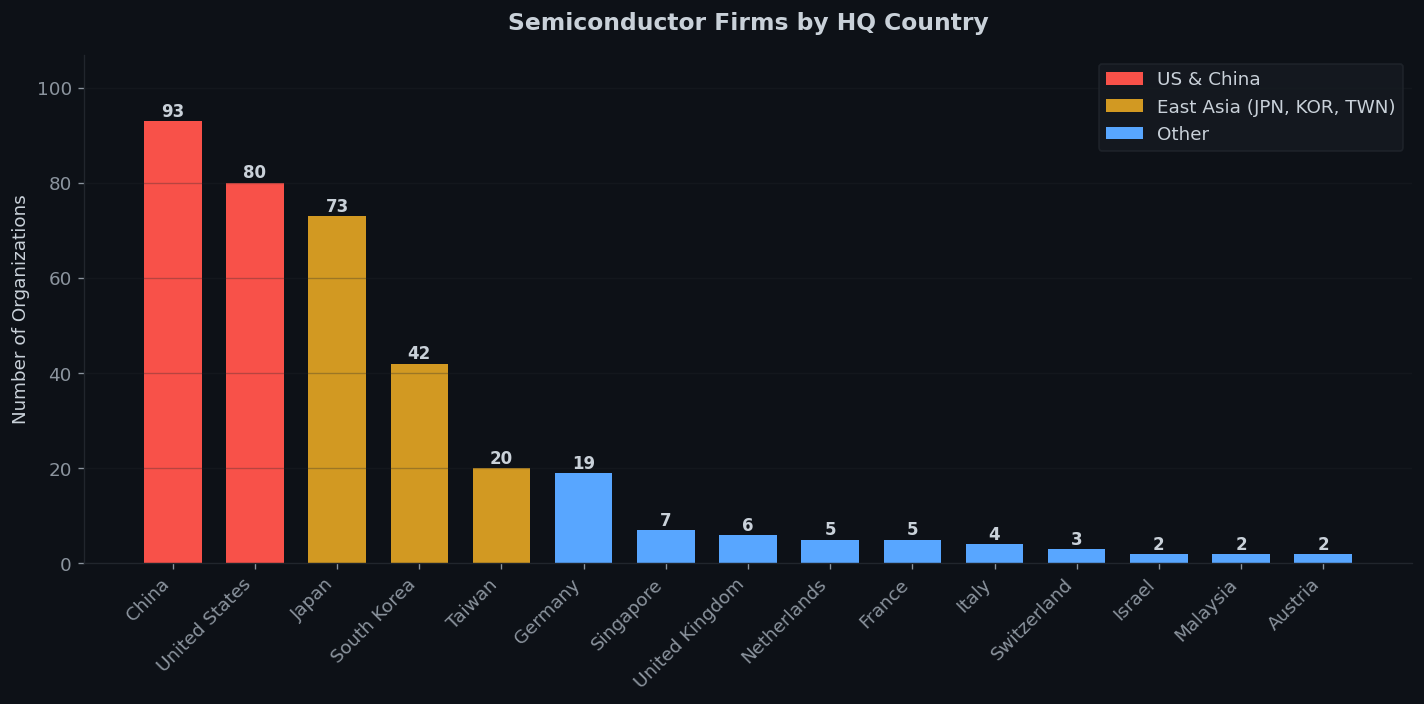

In [25]:
# ── Organizations by HQ country ──
orgs = providers.drop_duplicates('provider_id')
orgs = orgs[orgs['provider_type'] == 'organization']
country_counts = orgs['country'].value_counts().head(15)

# ISO to readable names
iso_names = {
    'CHN': 'China', 'USA': 'United States', 'JPN': 'Japan', 'KOR': 'South Korea',
    'TWN': 'Taiwan', 'DEU': 'Germany', 'SGP': 'Singapore', 'GBR': 'United Kingdom',
    'NLD': 'Netherlands', 'FRA': 'France', 'ITA': 'Italy', 'CHE': 'Switzerland',
    'AUT': 'Austria', 'SWE': 'Sweden', 'ISR': 'Israel', 'FIN': 'Finland',
    'BEL': 'Belgium', 'MYS': 'Malaysia', 'IND': 'India'
}

fig, ax = plt.subplots(figsize=(12, 6))

colors = [COLORS['danger'] if c in ['CHN', 'USA'] else 
          COLORS['accent3'] if c in ['JPN', 'KOR', 'TWN'] else 
          COLORS['accent'] for c in country_counts.index]

bars = ax.bar(
    [iso_names.get(c, c) for c in country_counts.index],
    country_counts.values,
    color=colors,
    edgecolor='none',
    width=0.7
)

for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10, fontweight='bold', color=COLORS['text'])

ax.set_title('Semiconductor Firms by HQ Country', pad=15)
ax.set_ylabel('Number of Organizations')
ax.set_ylim(0, country_counts.max() * 1.15)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['danger'], label='US & China'),
    Patch(facecolor=COLORS['accent3'], label='East Asia (JPN, KOR, TWN)'),
    Patch(facecolor=COLORS['accent'], label='Other'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.8,
          facecolor=COLORS['surface'], edgecolor=COLORS['border'])

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_03_country_orgs.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.4 Market Share Distribution

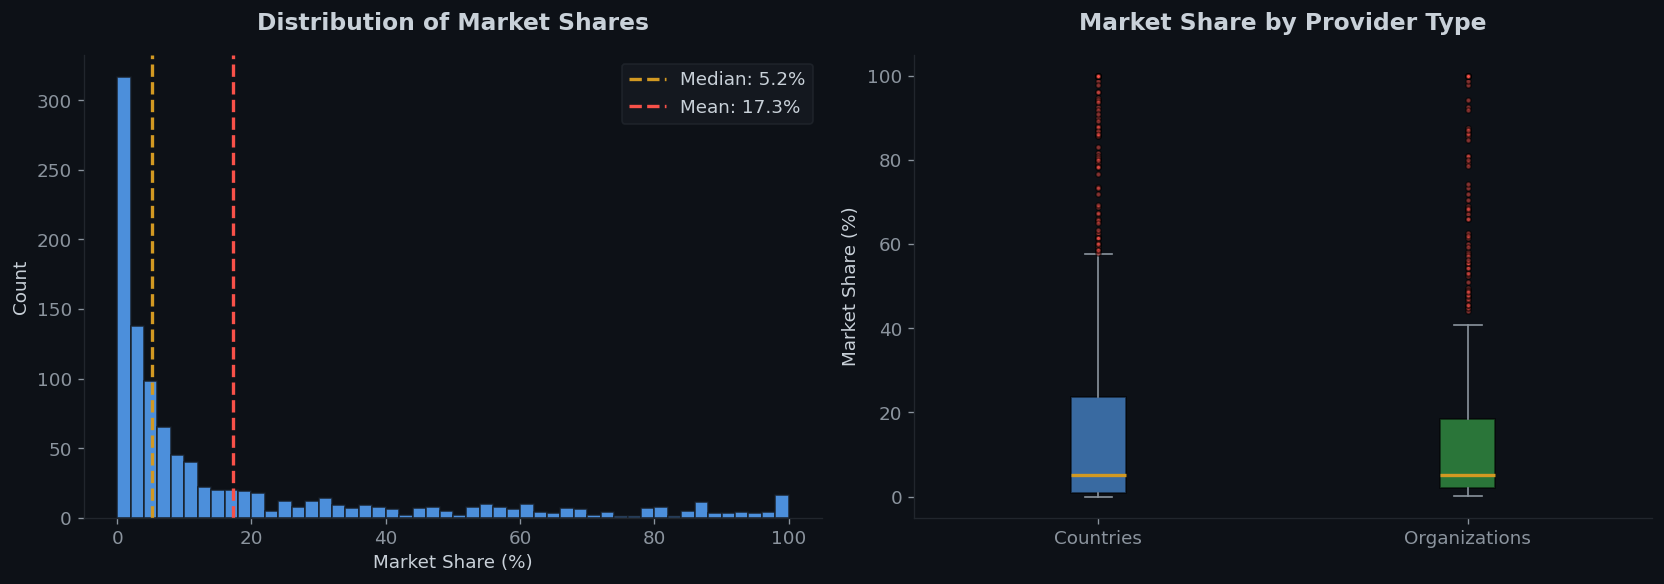

In [26]:
# ── Market share distribution (where available) ──
shares = master['share_provided'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(shares, bins=50, color=COLORS['accent'], edgecolor=COLORS['surface'], alpha=0.85)
ax1.axvline(shares.median(), color=COLORS['accent3'], linestyle='--', linewidth=2, label=f'Median: {shares.median():.1f}%')
ax1.axvline(shares.mean(), color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Mean: {shares.mean():.1f}%')
ax1.set_title('Distribution of Market Shares')
ax1.set_xlabel('Market Share (%)')
ax1.set_ylabel('Count')
ax1.legend(facecolor=COLORS['surface'], edgecolor=COLORS['border'])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Box plot by provider type
share_data = master[master['share_provided'].notna()].copy()
bp = ax2.boxplot(
    [share_data[share_data.provider_type == 'country']['share_provided'].values,
     share_data[share_data.provider_type == 'organization']['share_provided'].values],
    labels=['Countries', 'Organizations'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['accent'], alpha=0.6),
    medianprops=dict(color=COLORS['accent3'], linewidth=2),
    whiskerprops=dict(color=COLORS['text_dim']),
    capprops=dict(color=COLORS['text_dim']),
    flierprops=dict(markerfacecolor=COLORS['danger'], markersize=3, alpha=0.5)
)
bp['boxes'][1].set_facecolor(COLORS['accent2'])
ax2.set_title('Market Share by Provider Type')
ax2.set_ylabel('Market Share (%)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_04_share_dist.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.5 Country Market Share Across Input Types
Which countries dominate which types of semiconductor inputs?

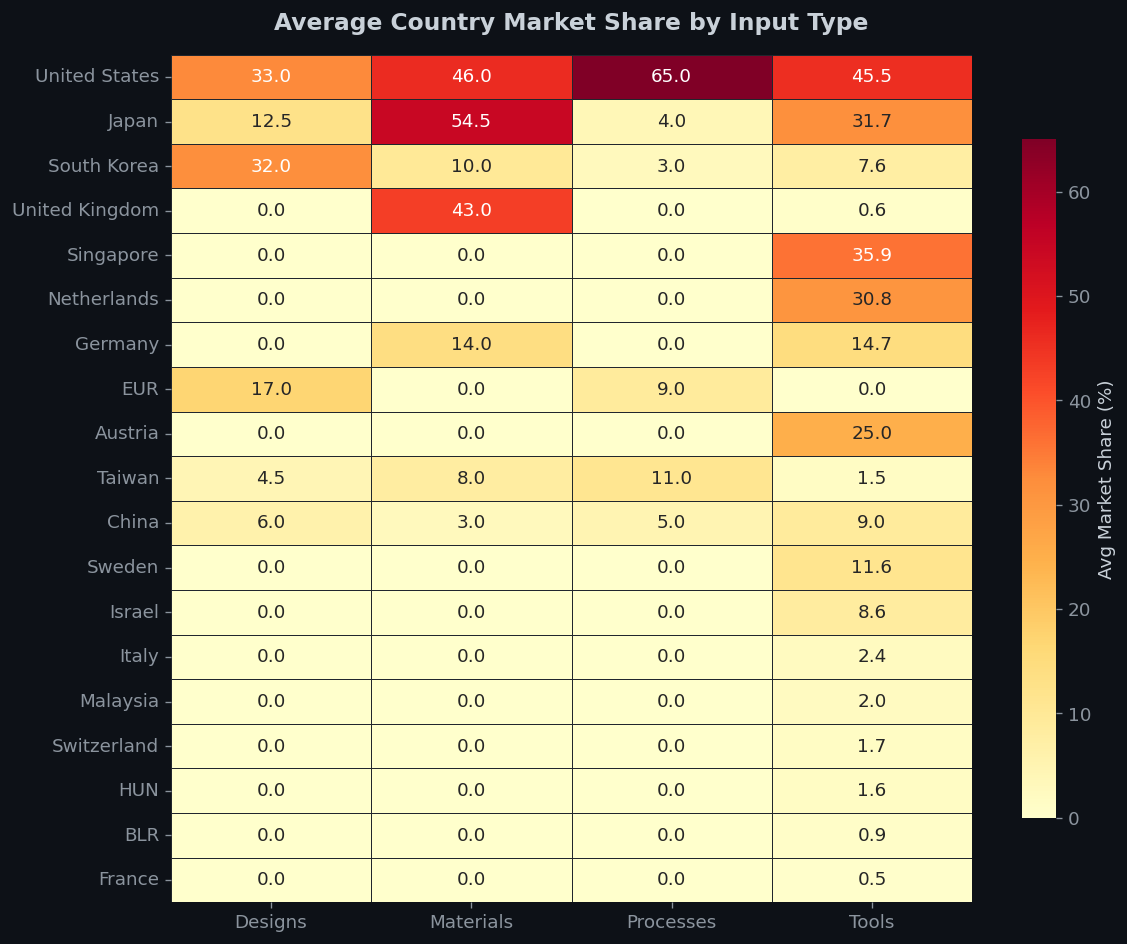

In [27]:
# ── Country × Input Type heatmap ──
country_data = master[
    (master['provider_type'] == 'country') & 
    (master['share_provided'].notna()) &
    (~master['provider_name'].str.contains('Various', case=False, na=False))
].copy()

country_data['country_label'] = country_data['provider_name'].map(iso_names).fillna(country_data['provider_name'])

# Average market share by country × input type
heatmap_data = country_data.pivot_table(
    index='country_label',
    columns='input_type',
    values='share_provided',
    aggfunc='mean'
).fillna(0)

# Sort by total average share
heatmap_data['total'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values('total', ascending=False).drop(columns='total')

# Rename columns for readability
col_rename = {
    'tool_resource': 'Tools',
    'material_resource': 'Materials',
    'process': 'Processes',
    'design_resource': 'Designs'
}
heatmap_data.columns = [col_rename.get(c, c) for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor=COLORS['border'],
    cbar_kws={'label': 'Avg Market Share (%)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Average Country Market Share by Input Type', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_05_country_heatmap.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.6 Supply Chain Chokepoints
Inputs where a single country holds >60% market share — the most critical dependencies.

In [28]:
# ── Identify chokepoints: inputs with highest single-country share ──
country_shares = master[
    (master['provider_type'] == 'country') & 
    (master['share_provided'].notna()) &
    (~master['provider_name'].str.contains('Various', case=False, na=False))
].copy()

# For each input, find the country with the largest share
top_country_per_input = country_shares.loc[
    country_shares.groupby('input_id')['share_provided'].idxmax()
][['input_id', 'input_name', 'provider_name', 'share_provided', 'input_type']].copy()

top_country_per_input['country_label'] = top_country_per_input['provider_name'].map(iso_names)

# Filter to chokepoints (>60% by a single country)
chokepoints = top_country_per_input[
    top_country_per_input['share_provided'] >= 60
].sort_values('share_provided', ascending=True)

print(f'Total inputs analyzed: {len(top_country_per_input)}')
print(f'Chokepoints (≥60% single-country share): {len(chokepoints)}')
print(f'\nDominant countries in chokepoints:')
print(chokepoints['country_label'].value_counts().to_string())

Total inputs analyzed: 94
Chokepoints (≥60% single-country share): 61

Dominant countries in chokepoints:
country_label
United States    29
Japan            15
Singapore         6
Netherlands       5
Germany           3
South Korea       1
China             1
Austria           1


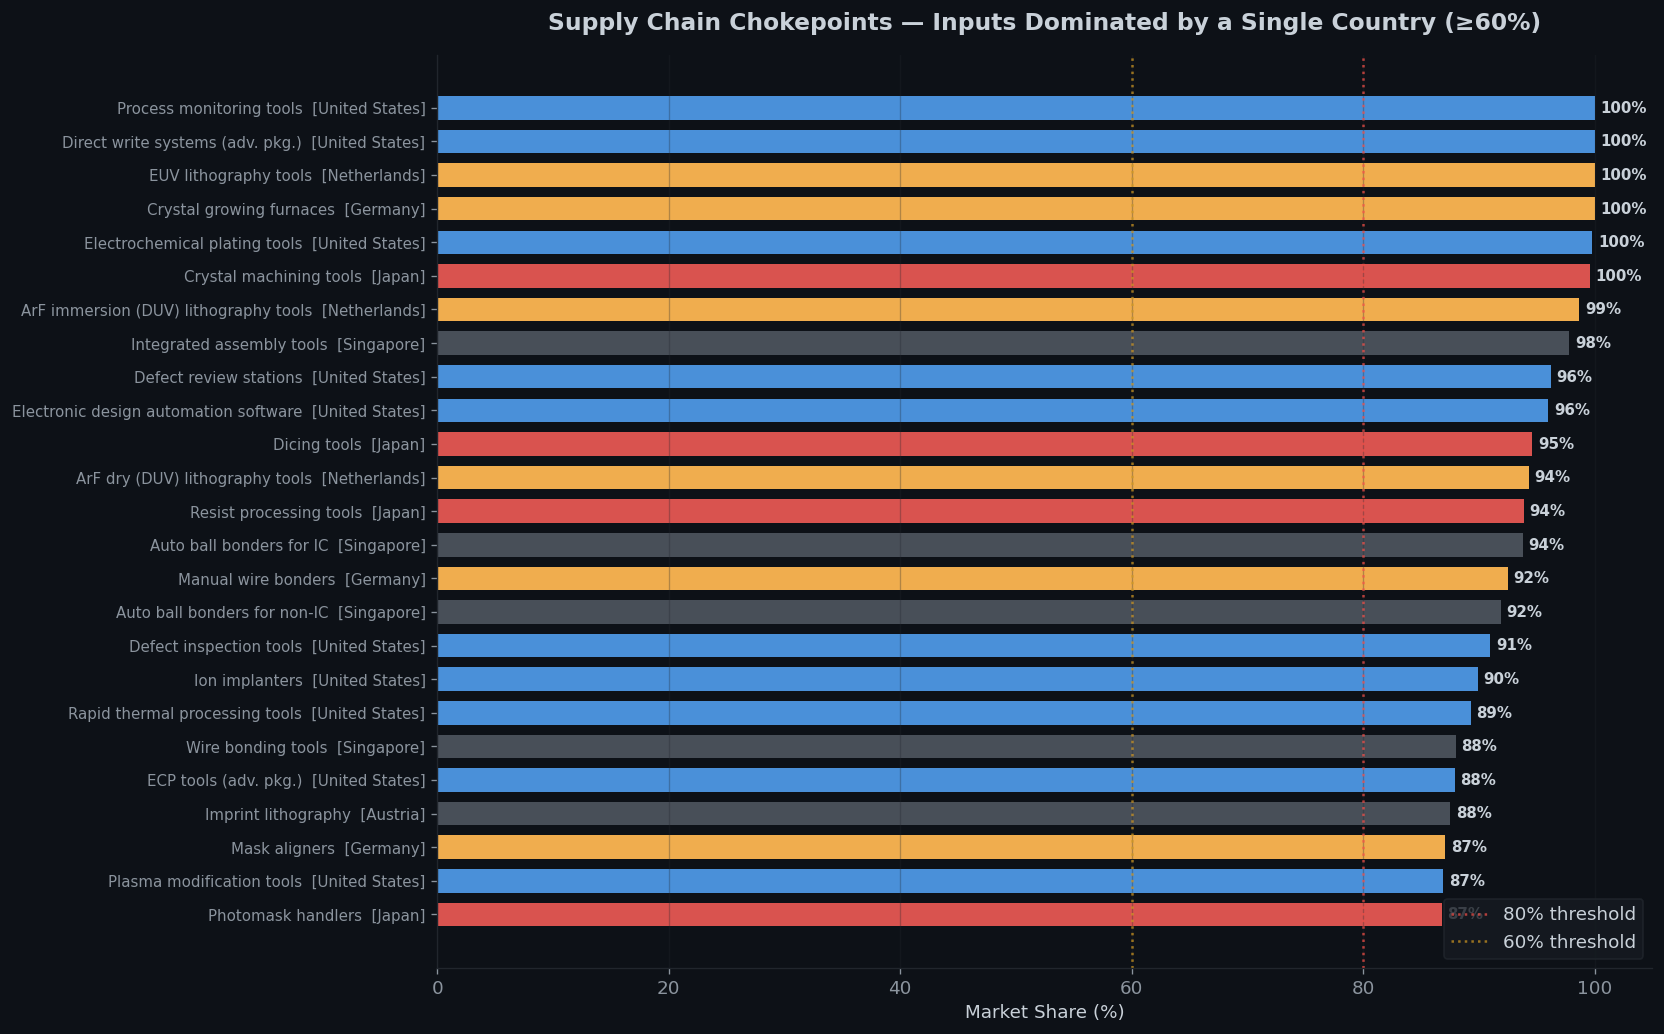

In [29]:
# ── Chokepoint visualization ──
if len(chokepoints) > 0:
    plot_data = chokepoints.tail(25)  # top 25 chokepoints
    
    country_colors = {
        'United States': '#4A90D9', 'Japan': '#D9534F', 'Netherlands': '#F0AD4E',
        'China': '#D9534F', 'South Korea': '#5CB85C', 'Taiwan': '#5CB85C',
        'Germany': '#F0AD4E',
    }
    bar_colors = [country_colors.get(c, COLORS['muted']) for c in plot_data['country_label']]
    
    fig, ax = plt.subplots(figsize=(14, max(8, len(plot_data) * 0.35)))
    
    bars = ax.barh(
        range(len(plot_data)),
        plot_data['share_provided'],
        color=bar_colors,
        height=0.7,
        edgecolor='none'
    )
    
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels([
        f"{row.input_name}  [{row.country_label}]" 
        for _, row in plot_data.iterrows()
    ], fontsize=9)
    
    for i, (_, row) in enumerate(plot_data.iterrows()):
        ax.text(row.share_provided + 0.5, i, f'{row.share_provided:.0f}%',
                va='center', fontsize=9, fontweight='bold', color=COLORS['text'])
    
    ax.axvline(x=80, color=COLORS['danger'], linestyle=':', alpha=0.7, label='80% threshold')
    ax.axvline(x=60, color=COLORS['accent3'], linestyle=':', alpha=0.7, label='60% threshold')
    
    ax.set_xlim(0, 105)
    ax.set_xlabel('Market Share (%)')
    ax.set_title('Supply Chain Chokepoints — Inputs Dominated by a Single Country (≥60%)', pad=15)
    ax.legend(loc='lower right', facecolor=COLORS['surface'], edgecolor=COLORS['border'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_06_chokepoints.png', bbox_inches='tight',
                facecolor=COLORS['bg'], dpi=150)
    plt.show()

### 6.7 Top Companies by Supply Chain Breadth
Which firms are present across the most inputs?

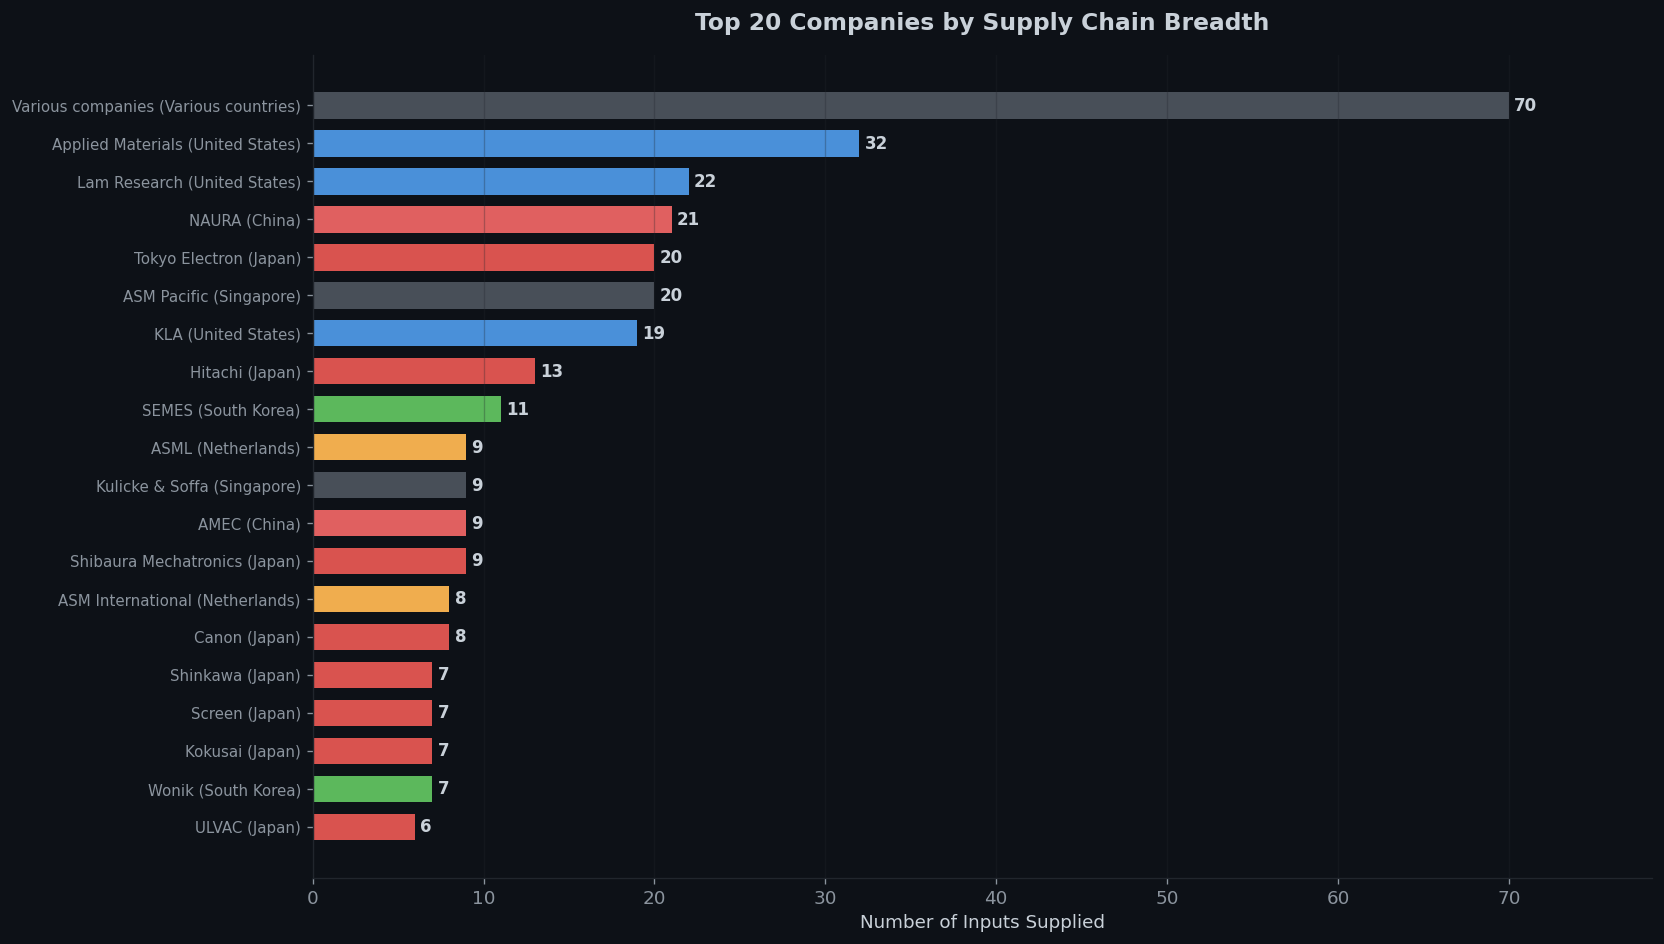

In [30]:
# ── Companies with widest supply chain coverage ──
org_data = master[master['provider_type'] == 'organization'].copy()

company_breadth = org_data.groupby(['provider_name', 'provider_hq_country']).agg(
    inputs_supplied=('input_id', 'nunique'),
    avg_share=('share_provided', 'mean'),
    max_share=('share_provided', 'max')
).reset_index().sort_values('inputs_supplied', ascending=False)

top20 = company_breadth.head(20).copy()
top20['label'] = top20['provider_name'] + ' (' + top20['provider_hq_country'].map(iso_names).fillna(top20['provider_hq_country']) + ')'

fig, ax = plt.subplots(figsize=(14, 8))

country_palette = {
    'USA': '#4A90D9', 'JPN': '#D9534F', 'NLD': '#F0AD4E', 'DEU': '#F0AD4E',
    'CHN': '#E06060', 'KOR': '#5CB85C', 'TWN': '#5CB85C', 'GBR': '#9B59B6'
}
bar_colors = [country_palette.get(c, COLORS['muted']) for c in top20['provider_hq_country']]

bars = ax.barh(
    range(len(top20)),
    top20['inputs_supplied'].values,
    color=bar_colors,
    height=0.7,
    edgecolor='none'
)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['label'].values, fontsize=9)
ax.invert_yaxis()

for i, val in enumerate(top20['inputs_supplied'].values):
    ax.text(val + 0.3, i, str(val), va='center', fontsize=10, 
            fontweight='bold', color=COLORS['text'])

ax.set_xlabel('Number of Inputs Supplied')
ax.set_title('Top 20 Companies by Supply Chain Breadth', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top20['inputs_supplied'].max() * 1.12)

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_07_company_breadth.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.8 Country Supply Chain Breadth vs Depth
A scatter view: how many inputs does each country participate in (breadth) vs. their average market share (depth)?

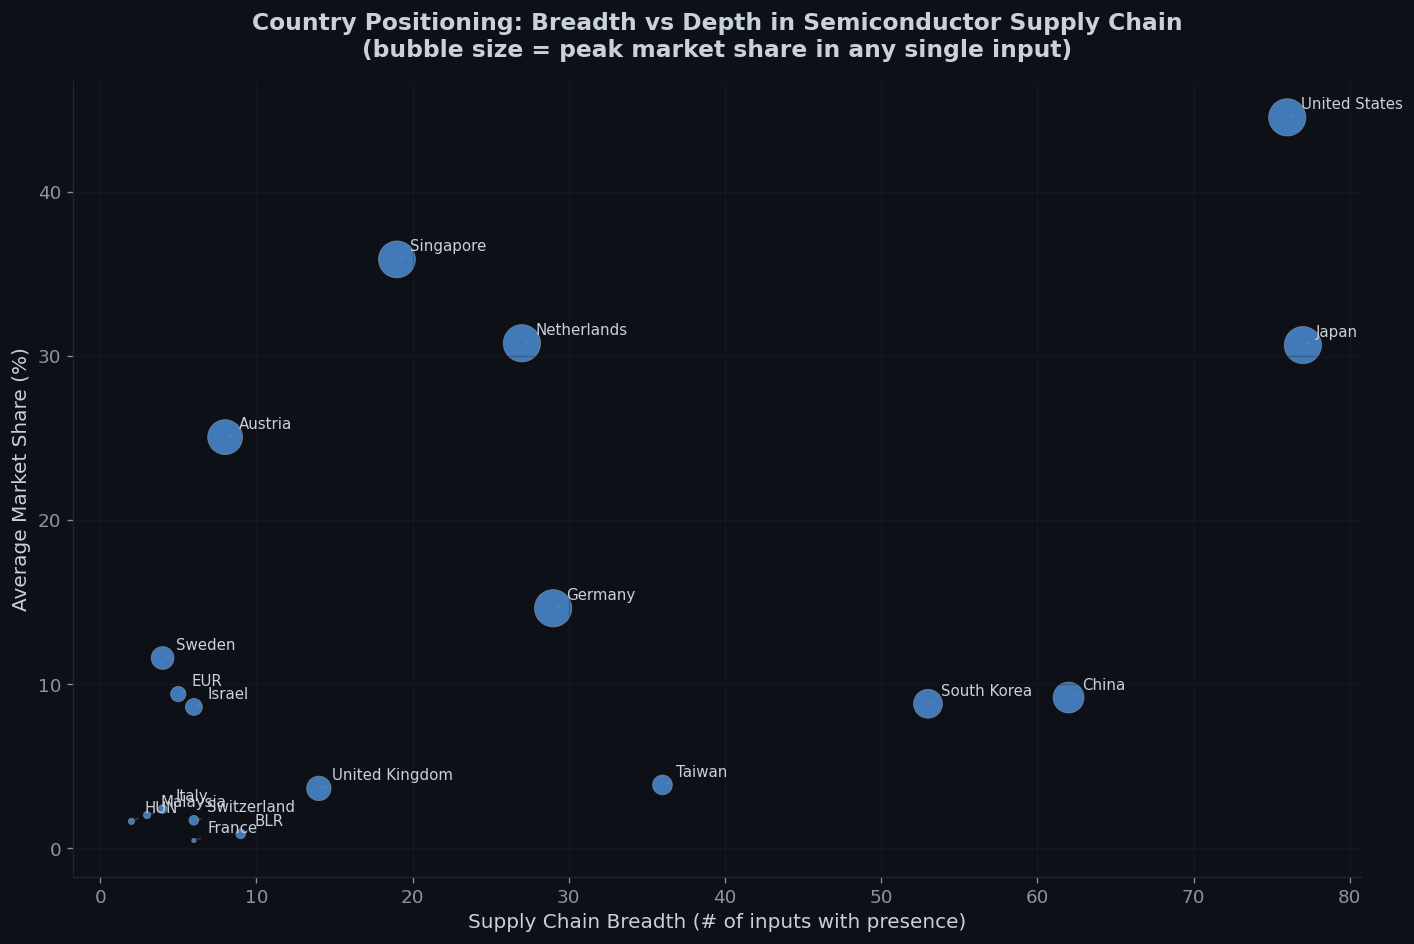

In [31]:
# ── Breadth vs Depth scatter ──
country_only = master[
    (master['provider_type'] == 'country') & 
    (master['share_provided'].notna()) &
    (~master['provider_name'].str.contains('Various', case=False, na=False))
].copy()

country_metrics = country_only.groupby('provider_name').agg(
    breadth=('input_id', 'nunique'),
    avg_share=('share_provided', 'mean'),
    max_share=('share_provided', 'max'),
    total_provisions=('input_id', 'count')
).reset_index()

country_metrics['country_label'] = country_metrics['provider_name'].map(iso_names).fillna(country_metrics['provider_name'])

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    country_metrics['breadth'],
    country_metrics['avg_share'],
    s=country_metrics['max_share'] * 5,  # size by peak dominance
    c=COLORS['accent'],
    alpha=0.7,
    edgecolors=COLORS['text_dim'],
    linewidths=0.5
)

# Label all points
for _, row in country_metrics.iterrows():
    ax.annotate(
        row['country_label'],
        (row['breadth'], row['avg_share']),
        xytext=(8, 5), textcoords='offset points',
        fontsize=9, color=COLORS['text'],
        arrowprops=dict(arrowstyle='-', color=COLORS['text_dim'], alpha=0.3)
    )

ax.set_xlabel('Supply Chain Breadth (# of inputs with presence)', fontsize=12)
ax.set_ylabel('Average Market Share (%)', fontsize=12)
ax.set_title('Country Positioning: Breadth vs Depth in Semiconductor Supply Chain\n'
             '(bubble size = peak market share in any single input)', pad=15)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_08_breadth_depth.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.9 Market Concentration by Input (HHI)
The Herfindahl-Hirschman Index measures concentration. Higher HHI = fewer dominant players.

In [32]:
# ── Calculate HHI for each input at the country level ──
country_shares_clean = master[
    (master['provider_type'] == 'country') & 
    (master['share_provided'].notna()) &
    (~master['provider_name'].str.contains('Various', case=False, na=False))
].copy()

# HHI = sum of squared market shares (0-10000 scale)
hhi_by_input = country_shares_clean.groupby(['input_id', 'input_name', 'input_type']).apply(
    lambda g: (g['share_provided'] ** 2).sum()
).reset_index(name='hhi')

hhi_by_input['concentration'] = pd.cut(
    hhi_by_input['hhi'],
    bins=[0, 1500, 2500, 10000],
    labels=['Competitive (<1500)', 'Moderate (1500-2500)', 'Highly Concentrated (>2500)']
)

print('Market Concentration Distribution:')
print(hhi_by_input['concentration'].value_counts().to_string())
print(f'\nHHI stats:')
print(hhi_by_input['hhi'].describe().to_string())

Market Concentration Distribution:
concentration
Highly Concentrated (>2500)    86
Moderate (1500-2500)            5
Competitive (<1500)             0

HHI stats:
count       91.000000
mean      5928.827692
std       2239.486405
min       1761.060000
25%       4244.800000
50%       5467.640000
75%       7662.905000
max      10000.000000


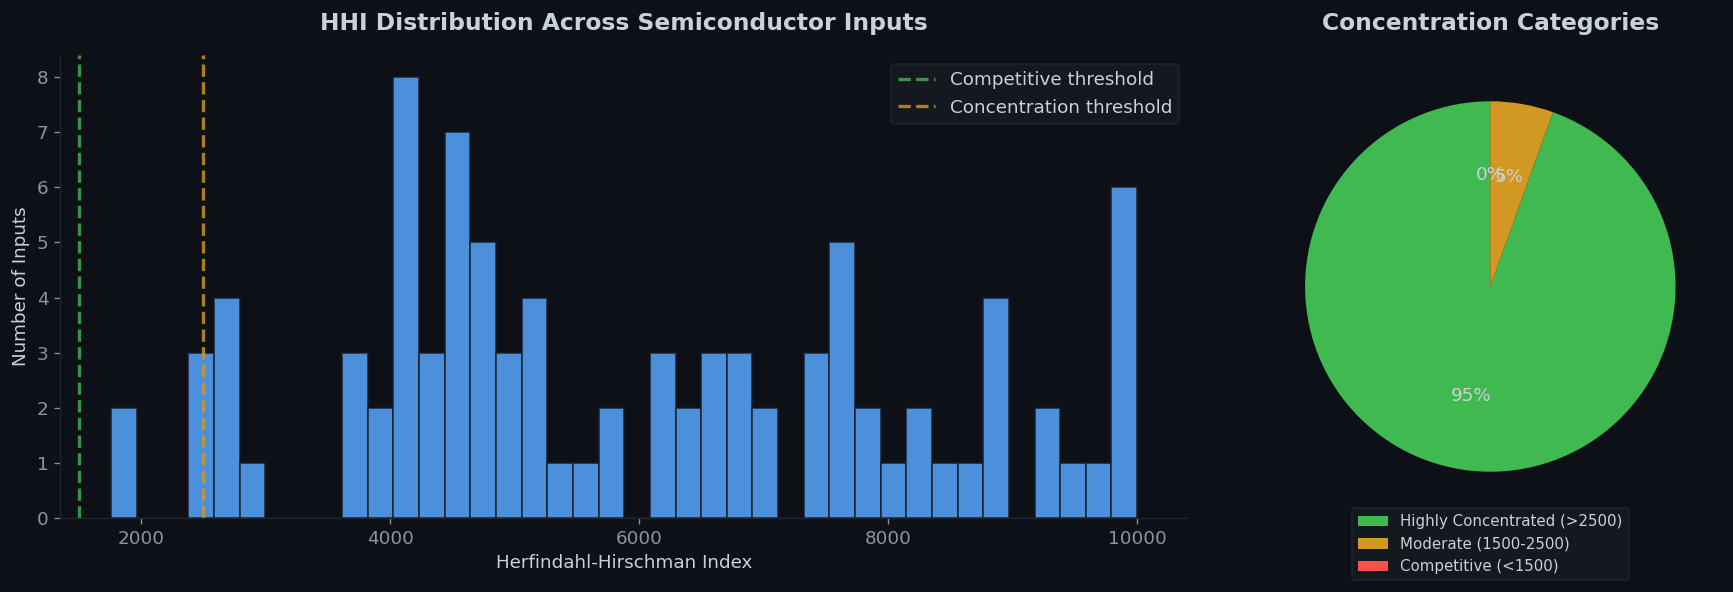

In [33]:
# ── HHI distribution plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

# Histogram of HHI values
ax1.hist(hhi_by_input['hhi'], bins=40, color=COLORS['accent'], edgecolor=COLORS['surface'], alpha=0.85)
ax1.axvline(1500, color=COLORS['accent2'], linestyle='--', linewidth=2, alpha=0.8, label='Competitive threshold')
ax1.axvline(2500, color=COLORS['accent3'], linestyle='--', linewidth=2, alpha=0.8, label='Concentration threshold')
ax1.set_title('HHI Distribution Across Semiconductor Inputs')
ax1.set_xlabel('Herfindahl-Hirschman Index')
ax1.set_ylabel('Number of Inputs')
ax1.legend(facecolor=COLORS['surface'], edgecolor=COLORS['border'])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Pie chart of concentration categories
conc_counts = hhi_by_input['concentration'].value_counts()
pie_colors = [COLORS['accent2'], COLORS['accent3'], COLORS['danger']]
wedges, texts, autotexts = ax2.pie(
    conc_counts.values,
    labels=None,
    autopct='%1.0f%%',
    colors=pie_colors[:len(conc_counts)],
    startangle=90,
    textprops={'color': COLORS['text'], 'fontsize': 11}
)
ax2.legend(conc_counts.index, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           frameon=True, facecolor=COLORS['surface'], edgecolor=COLORS['border'],
           fontsize=9)
ax2.set_title('Concentration Categories')

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_09_hhi.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

### 6.10 Supply Chain Relationships — Sequence Table Analysis

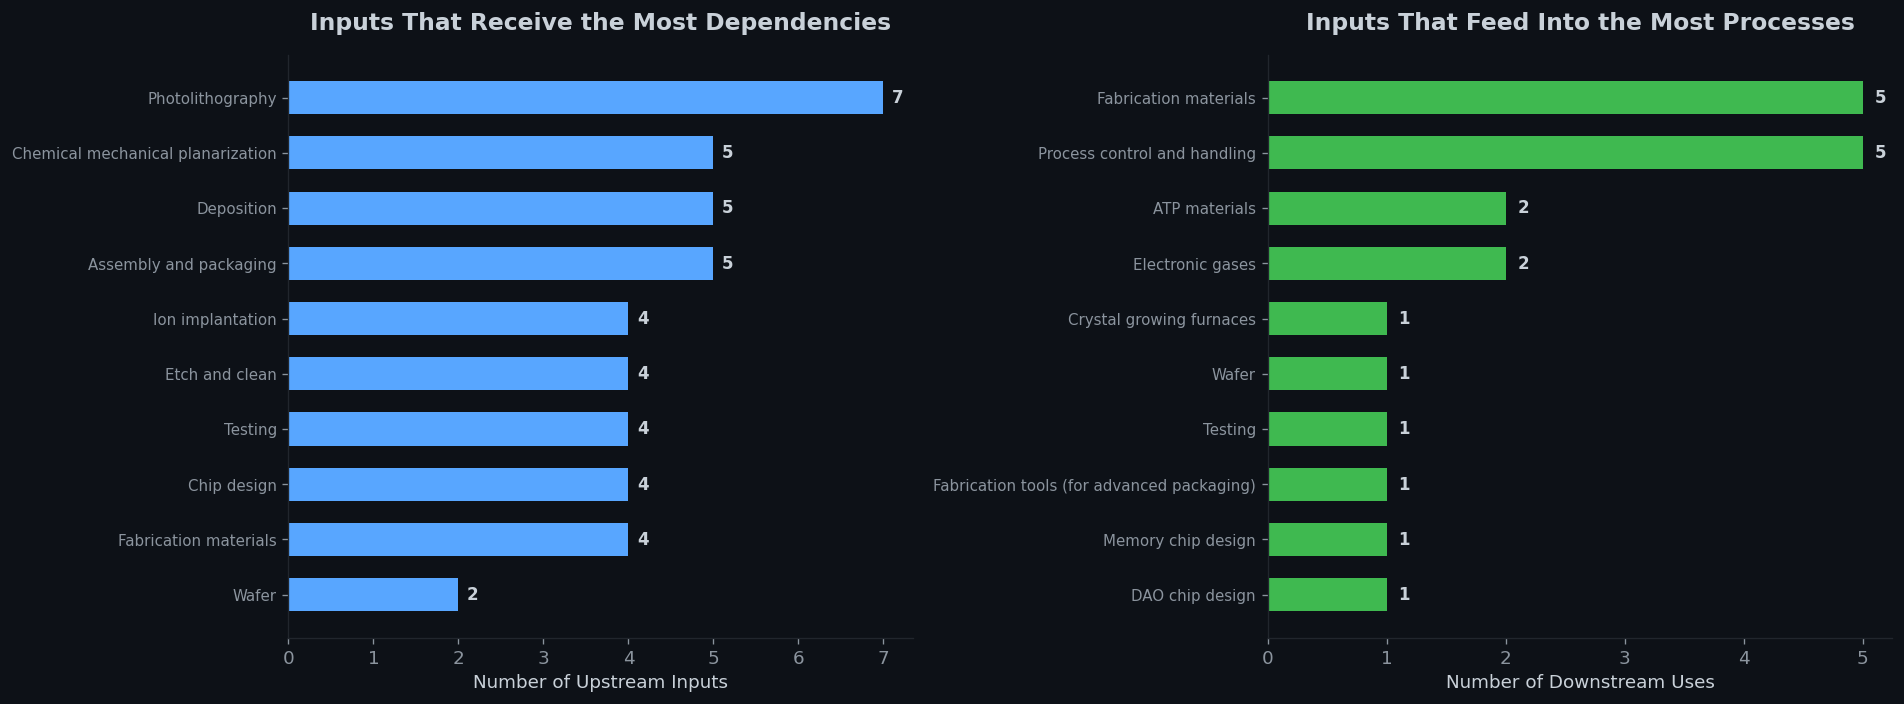

In [34]:
# ── Sequence relationship analysis ──
goes_into = sequence[sequence['goes_into_id'].notna()].copy()
is_type_of = sequence[sequence['is_type_of_id'].notna()].copy()

# Most connected inputs (by "goes into" relationships)
# Which inputs receive the most other inputs?
receives = goes_into['goes_into_name'].value_counts().head(10)
# Which inputs feed into the most other inputs?
feeds = goes_into['input_name'].value_counts().head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Inputs that receive the most
ax1.barh(range(len(receives)), receives.values, color=COLORS['accent'], height=0.6)
ax1.set_yticks(range(len(receives)))
ax1.set_yticklabels(receives.index, fontsize=9)
ax1.invert_yaxis()
ax1.set_title('Inputs That Receive the Most Dependencies')
ax1.set_xlabel('Number of Upstream Inputs')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for i, v in enumerate(receives.values):
    ax1.text(v + 0.1, i, str(v), va='center', fontsize=10, fontweight='bold', color=COLORS['text'])

# Inputs that feed into the most
ax2.barh(range(len(feeds)), feeds.values, color=COLORS['accent2'], height=0.6)
ax2.set_yticks(range(len(feeds)))
ax2.set_yticklabels(feeds.index, fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Inputs That Feed Into the Most Processes')
ax2.set_xlabel('Number of Downstream Uses')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for i, v in enumerate(feeds.values):
    ax2.text(v + 0.1, i, str(v), va='center', fontsize=10, fontweight='bold', color=COLORS['text'])

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/viz_10_sequence.png', bbox_inches='tight',
            facecolor=COLORS['bg'], dpi=150)
plt.show()

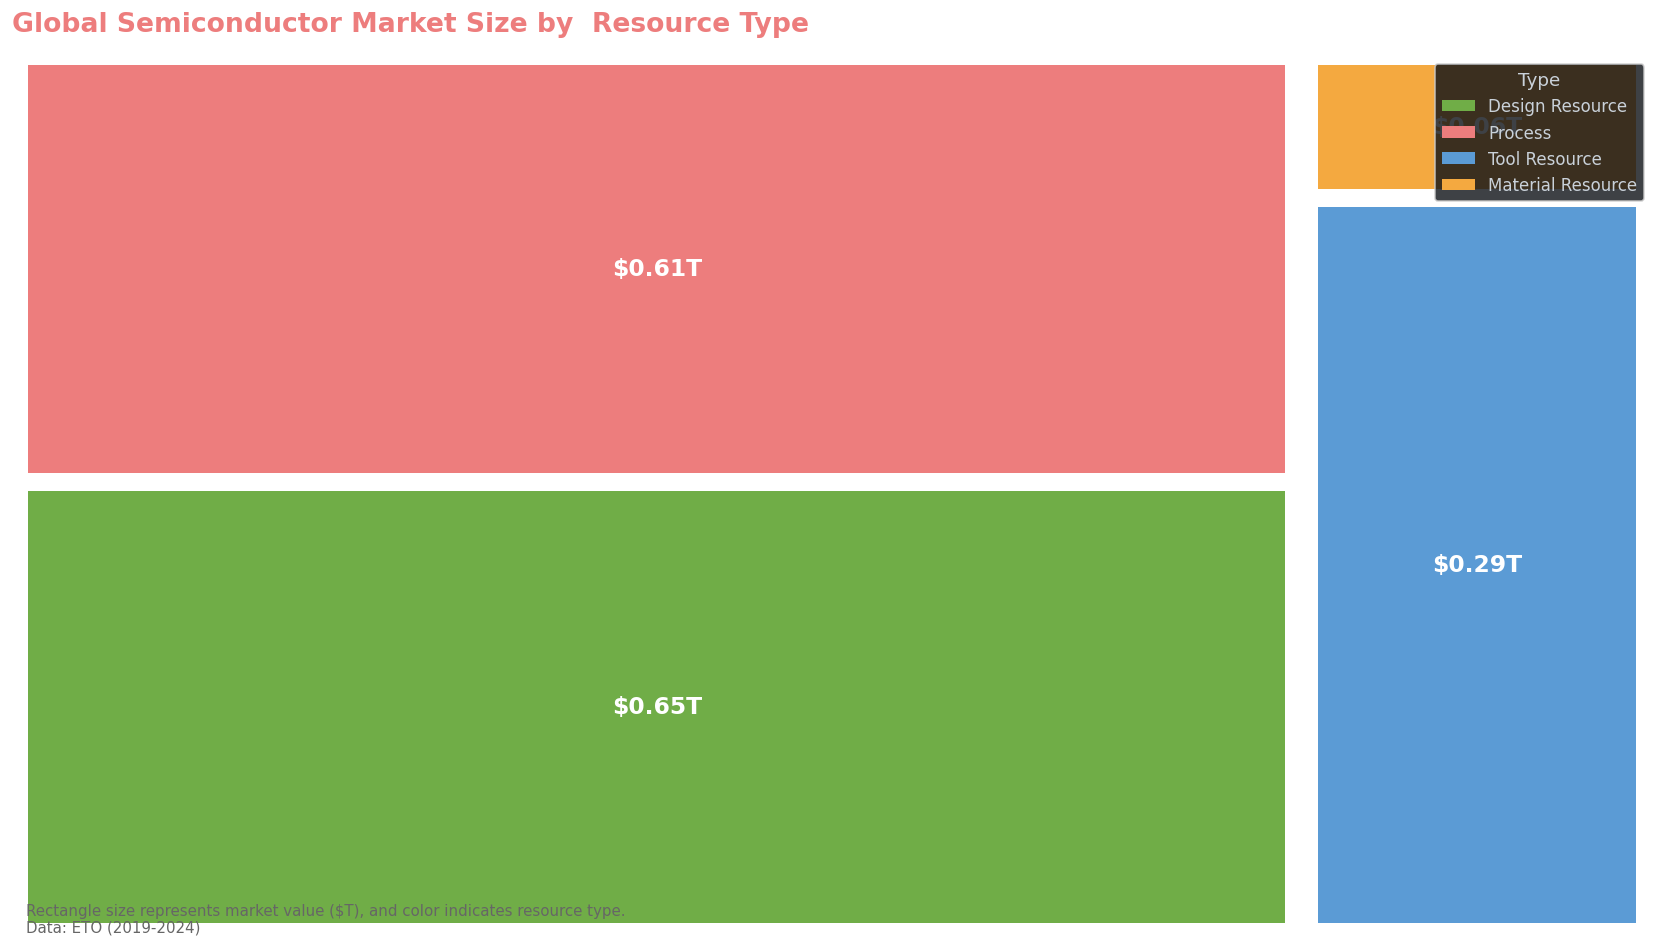

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import squarify

semi = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_master.csv')
inputs = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/inputs.csv')

# Parse market size from string to numeric (trillions)
def parse_market_size(s):
    if pd.isna(s):
        return 0
    s = str(s).replace(',', '')
    for match in [s]:
        import re
        nums = re.findall(r'[\d.]+', match.replace('$', '').replace(',', ''))
        if nums:
            val = float(nums[0])
            if 'billion' in match.lower():
                return val / 1000  # convert to trillions
            elif 'million' in match.lower():
                return val / 1e6
            elif 'trillion' in match.lower():
                return val
            else:
                return val / 1000  # assume billions
    return 0

inputs['market_size_T'] = inputs['market_share_chart_global_market_size_info'].apply(parse_market_size)

# Aggregate by type
type_market = inputs.groupby('type')['market_size_T'].sum().sort_values(ascending=False)

type_labels = {
    'tool_resource': 'Tool Resource', 'material_resource': 'Material Resource',
    'process': 'Process', 'design_resource': 'Design Resource', 'ultimate_output': 'Ultimate Output'
}
type_colors = {
    'tool_resource': '#5B9BD5', 'design_resource': '#70AD47',
    'process': '#ED7D7D', 'material_resource': '#F4A940', 'ultimate_output': '#A5A5A5'
}

# Filter out zero/tiny
type_market = type_market[type_market > 0.01]

labels = [f"${v:.2f}T" for v in type_market.values]
colors = [type_colors.get(t, '#999') for t in type_market.index]

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

squarify.plot(
    sizes=type_market.values, label=labels, color=colors,
    alpha=1.0, ax=ax, text_kwargs={'fontsize': 14, 'color': 'white', 'fontweight': 'bold'},
    pad=2
)

ax.set_title('Global Semiconductor Market Size by  Resource Type',
             fontsize=16, fontweight='bold', color='#ED7D7D', loc='left', pad=15)
ax.axis('off')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=type_colors[k], label=type_labels[k])
                   for k in type_market.index if k in type_colors]
ax.legend(handles=legend_elements, loc='upper right', title='Type',
          fontsize=10, title_fontsize=11, frameon=True)

fig.text(0.02, 0.02, 'Rectangle size represents market value ($T), and color indicates resource type.\nData: ETO (2019-2024)',
         fontsize=9, color='#666')

plt.tight_layout()
plt.savefig('viz_semi_01_treemap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

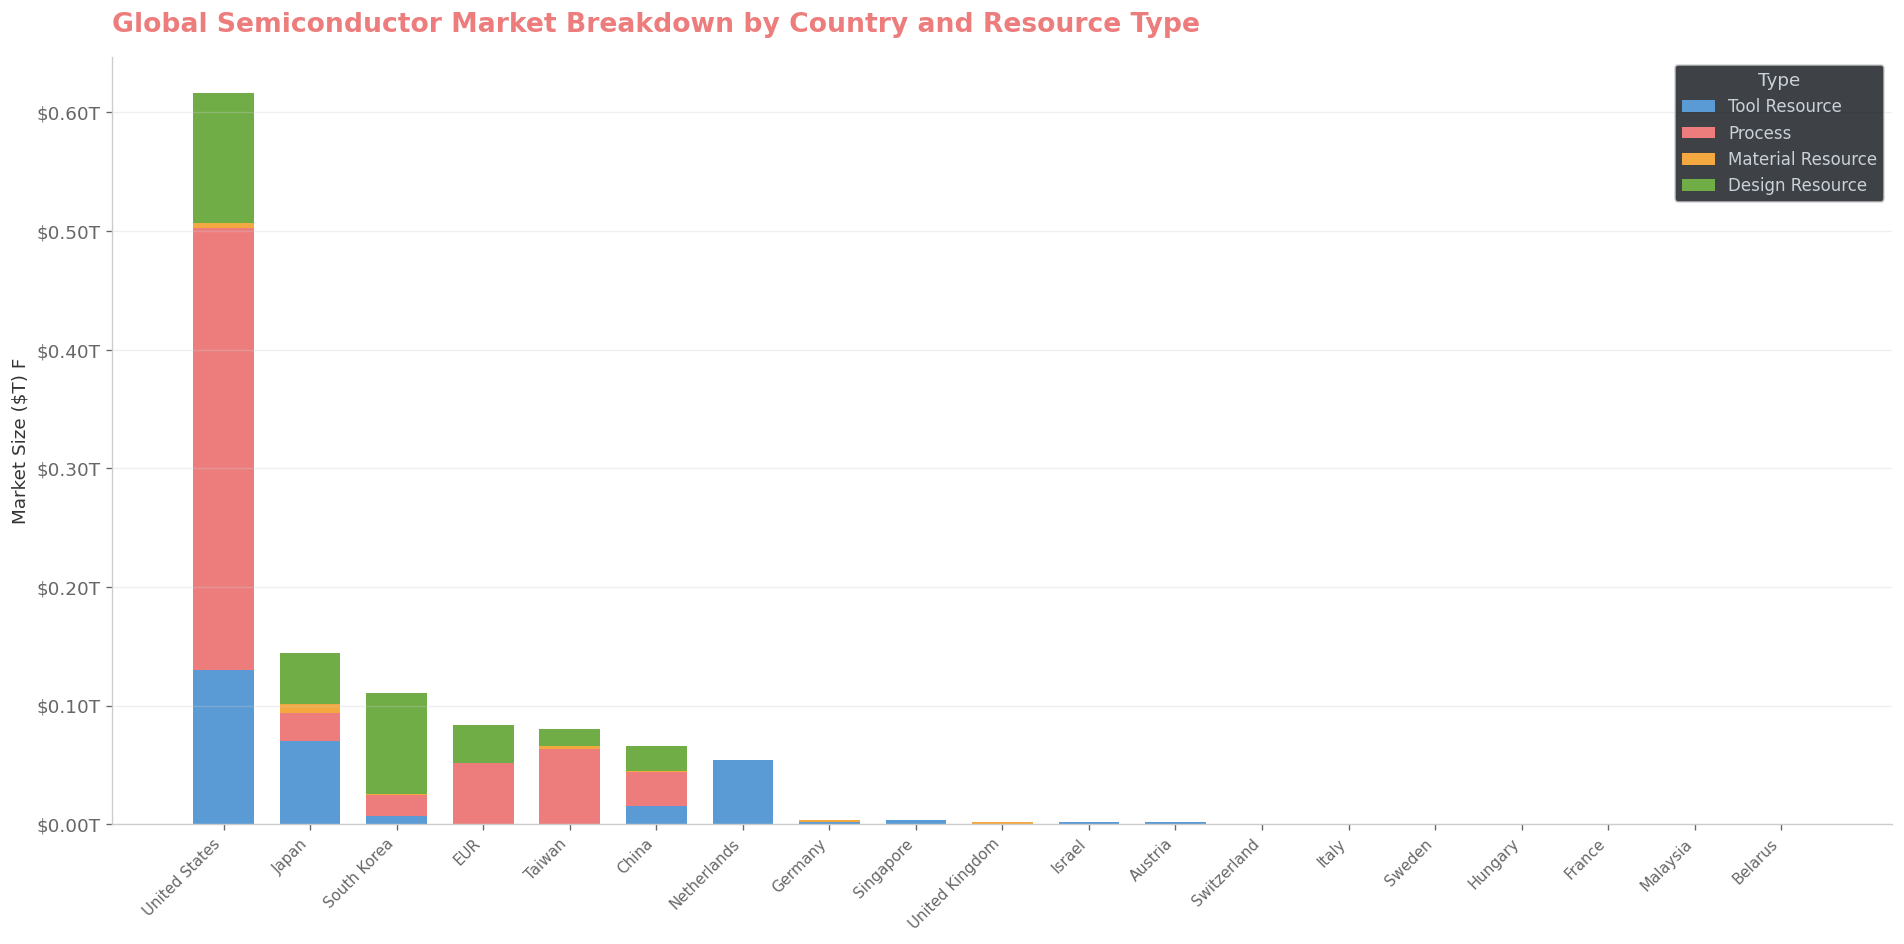

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import re

ISO_TO_NAME = {
    'USA': 'United States', 'CHN': 'China', 'JPN': 'Japan', 'KOR': 'South Korea',
    'TWN': 'Taiwan', 'DEU': 'Germany', 'SGP': 'Singapore', 'GBR': 'United Kingdom',
    'NLD': 'Netherlands', 'FRA': 'France', 'ITA': 'Italy', 'CHE': 'Switzerland',
    'AUT': 'Austria', 'SWE': 'Sweden', 'ISR': 'Israel', 'FIN': 'Finland',
    'BEL': 'Belgium', 'MYS': 'Malaysia', 'IND': 'India', 'CAN': 'Canada',
    'BLR': 'Belarus', 'CZE': 'Czech Republic', 'HUN': 'Hungary',
}

def parse_market_size(s):
    if pd.isna(s):
        return 0
    s = str(s).replace(',', '')
    nums = re.findall(r'[\d.]+', s.replace('$', ''))
    if nums:
        val = float(nums[0])
        if 'billion' in s.lower():
            return val / 1000
        elif 'million' in s.lower():
            return val / 1e6
        elif 'trillion' in s.lower():
            return val
        else:
            return val / 1000
    return 0

inputs['market_size_T'] = inputs['market_share_chart_global_market_size_info'].apply(parse_market_size)

# Prepare inputs with market size and renamed type column
inputs_with_market = inputs[['input_id', 'type', 'market_size_T']].copy()
inputs_with_market = inputs_with_market[inputs_with_market.market_size_T > 0]
inputs_with_market = inputs_with_market.rename(columns={'type': 'resource_type'})

# Merge semiconductor master with input market sizes
semi_with_market = semi.merge(
    inputs_with_market, left_on='input_id', right_on='input_id', how='inner'
)

# Filter to country-level providers with share data
semi_country = semi_with_market[
    (semi_with_market.provider_type == 'country') &
    (semi_with_market.share_provided.notna()) &
    (~semi_with_market.provider_name.str.contains('Various', case=False, na=False))
].copy()

semi_country['country_name'] = semi_country['provider_name'].map(ISO_TO_NAME).fillna(semi_country['provider_name'])
semi_country['market_value_T'] = semi_country['share_provided'] / 100 * semi_country['market_size_T']

# Pivot: country × resource_type
country_type = semi_country.groupby(['country_name', 'resource_type'])['market_value_T'].sum().reset_index()
ct_pivot = country_type.pivot_table(index='country_name', columns='resource_type', values='market_value_T', fill_value=0)
ct_pivot['total'] = ct_pivot.sum(axis=1)
ct_pivot = ct_pivot.sort_values('total', ascending=False).drop(columns='total')

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

plot_types = ['tool_resource', 'process', 'material_resource', 'design_resource']
plot_labels = ['Tool Resource', 'Process', 'Material Resource', 'Design Resource']
plot_colors = ['#5B9BD5', '#ED7D7D', '#F4A940', '#70AD47']

bottom = np.zeros(len(ct_pivot))
x = np.arange(len(ct_pivot))

for ptype, label, color in zip(plot_types, plot_labels, plot_colors):
    if ptype in ct_pivot.columns:
        vals = ct_pivot[ptype].values
        ax.bar(x, vals, bottom=bottom, color=color, label=label, width=0.7, edgecolor='none')
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(ct_pivot.index, rotation=45, ha='right', fontsize=9, color='#333')
ax.set_ylabel('Market Size ($T) F', fontsize=11, color='#333')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.2f}T'))

ax.set_title('Global Semiconductor Market Breakdown by Country and Resource Type',
             fontsize=16, fontweight='bold', color='#ED7D7D', loc='left', pad=15)

ax.legend(title='Type', loc='upper right', fontsize=10, title_fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
ax.tick_params(colors='#666')
ax.grid(axis='y', alpha=0.3, color='#ccc')

plt.tight_layout()
plt.savefig('viz_semi_02_country_breakdown.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# Top 5 inputs by market size
top5 = inputs[inputs.market_size_T > 0].nlargest(10, 'market_size_T')[
    ['input_name', 'type', 'market_size_T']
].copy()

type_colors_map = {
    'tool_resource': '#5B9BD5', 'design_resource': '#70AD47',
    'process': '#ED7D7D', 'material_resource': '#F4A940',
}

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y = np.arange(len(top5))
colors = [type_colors_map.get(t, '#999') for t in top5['type']]
bars = ax.barh(y, top5['market_size_T'], color=colors, height=0.65, edgecolor='none')

ax.set_yticks(y)
ax.set_yticklabels(top5['input_name'], fontsize=11, color='#333')
ax.invert_yaxis()

# Value labels inside bars
for bar, val in zip(bars, top5['market_size_T']):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'${val:.2f}T', ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')

ax.set_title('Top 5  Markets in Semiconductor Supply Chain',
             fontsize=16, fontweight='bold', color='#ED7D7D', loc='left', pad=15)

# Legend
present_types = top5['type'].unique()
legend_elements = [Patch(facecolor=type_colors_map[t], label=type_labels.get(t, t))
                   for t in present_types if t in type_colors_map]
ax.legend(handles=legend_elements, title='Type', loc='upper right', fontsize=10, title_fontsize=11)

ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
ax.tick_params(colors='#666')
ax.set_xlim(0, top5.market_size_T.max() * 1.05)
ax.xaxis.set_visible(False)

plt.tight_layout()
plt.savefig('viz_semi_03_top5_markets.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

NameError: name 'inputs' is not defined

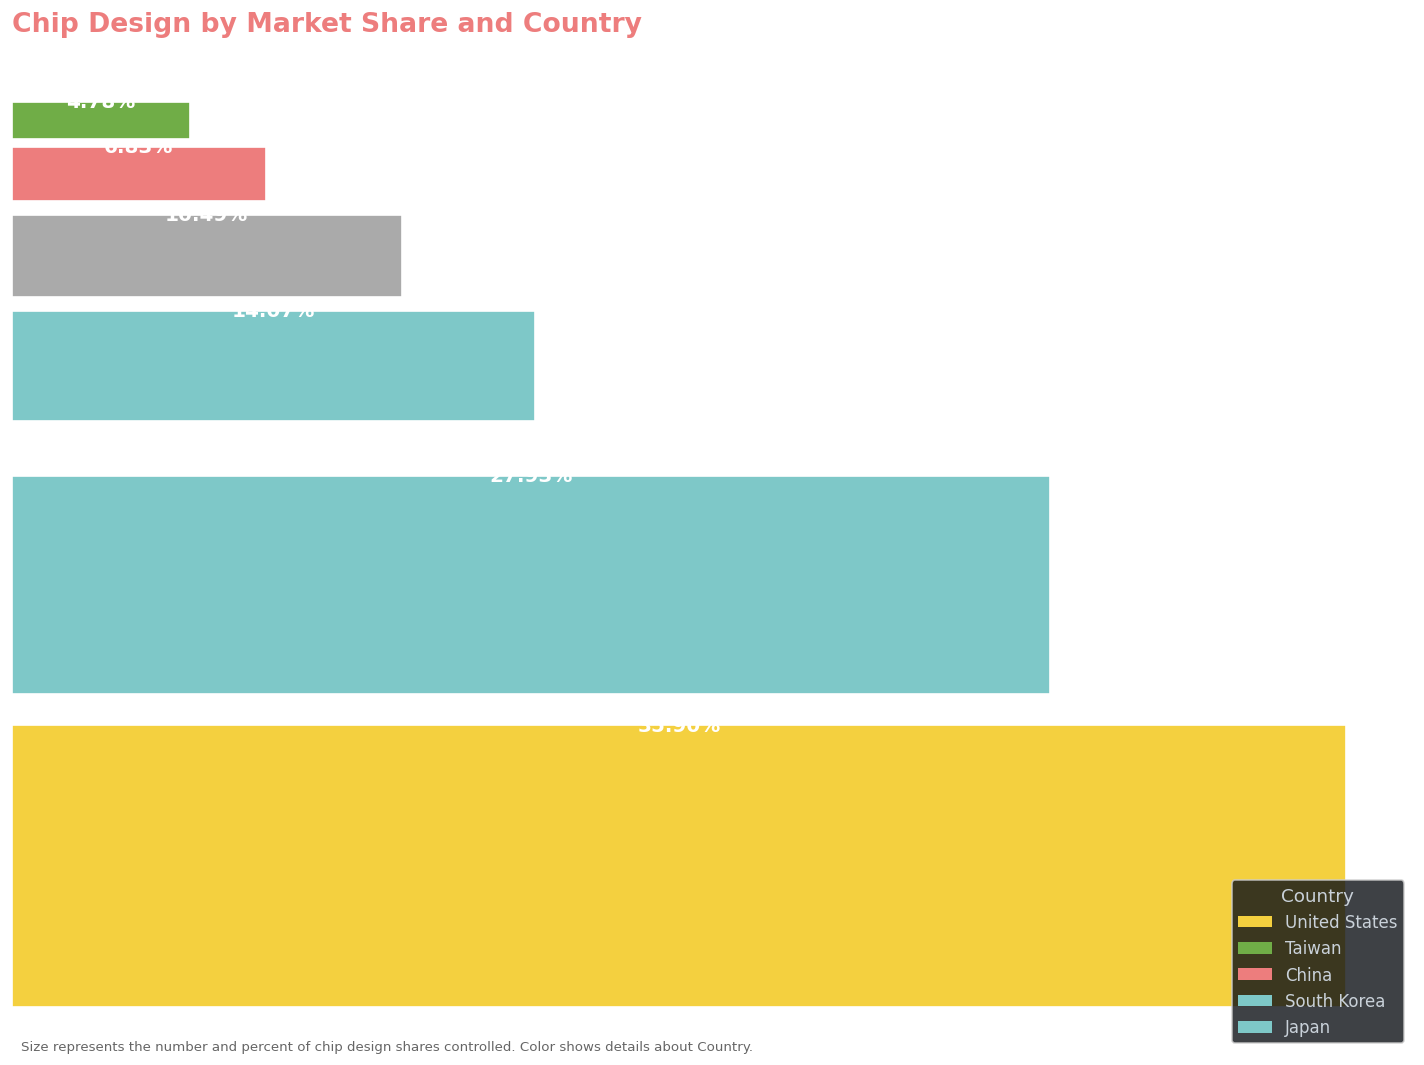

In [40]:
# Get chip design related inputs and country shares
chip_design_inputs = inputs[inputs.type == 'design_resource']['input_id'].tolist()

chip_shares = semi[
    (semi.provider_type == 'country') &
    (semi.input_id.isin(chip_design_inputs)) &
    (semi.share_provided.notna()) &
    (~semi.provider_name.str.contains('Various', case=False, na=False))
].copy()

chip_shares['country_name'] = chip_shares['provider_name'].map(ISO_TO_NAME).fillna(chip_shares['provider_name'])

# Aggregate across all design inputs (weighted by market size)
chip_shares = chip_shares.merge(
    inputs[['input_id', 'market_size_T']], on='input_id', how='left'
)
chip_shares['weighted_share'] = chip_shares['share_provided'] * chip_shares['market_size_T']
country_chip = chip_shares.groupby('country_name').agg(
    weighted_share=('weighted_share', 'sum'),
    total_market=('market_size_T', 'sum')
).reset_index()
country_chip['pct'] = country_chip['weighted_share'] / country_chip['weighted_share'].sum() * 100
country_chip = country_chip.sort_values('pct', ascending=False)

# Plot as stacked horizontal marimekko-style
country_colors = {
    'United States': '#F4D03F', 'Taiwan': '#70AD47', 'China': '#ED7D7D',
    'South Korea': '#7EC8C8', 'Japan': '#7EC8C8',
}

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y_start = 0
for _, row in country_chip.iterrows():
    height = row['pct'] / 100 * 8  # scale for visual
    color = country_colors.get(row['country_name'], '#AAA')
    width = row['pct'] / country_chip['pct'].max()  # proportional width
    ax.barh(y_start, width, height=height, color=color, edgecolor='white', linewidth=1)
    ax.text(width / 2, y_start + height / 2, f"{row['pct']:.2f}%",
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    y_start += height

ax.set_title('Chip Design by Market Share and Country',
             fontsize=16, fontweight='bold', color='#ED7D7D', loc='left', pad=15)

# Legend
legend_elements = [Patch(facecolor=color, label=name) 
                   for name, color in country_colors.items()
                   if name in country_chip.country_name.values]
ax.legend(handles=legend_elements, title='Country', loc='lower right', fontsize=10, title_fontsize=11)

ax.axis('off')
fig.text(0.02, 0.02,
         "Size represents the number and percent of chip design shares controlled. Color shows details about Country.",
         fontsize=8, color='#666')

plt.tight_layout()
plt.savefig('viz_semi_04_chip_design_share.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

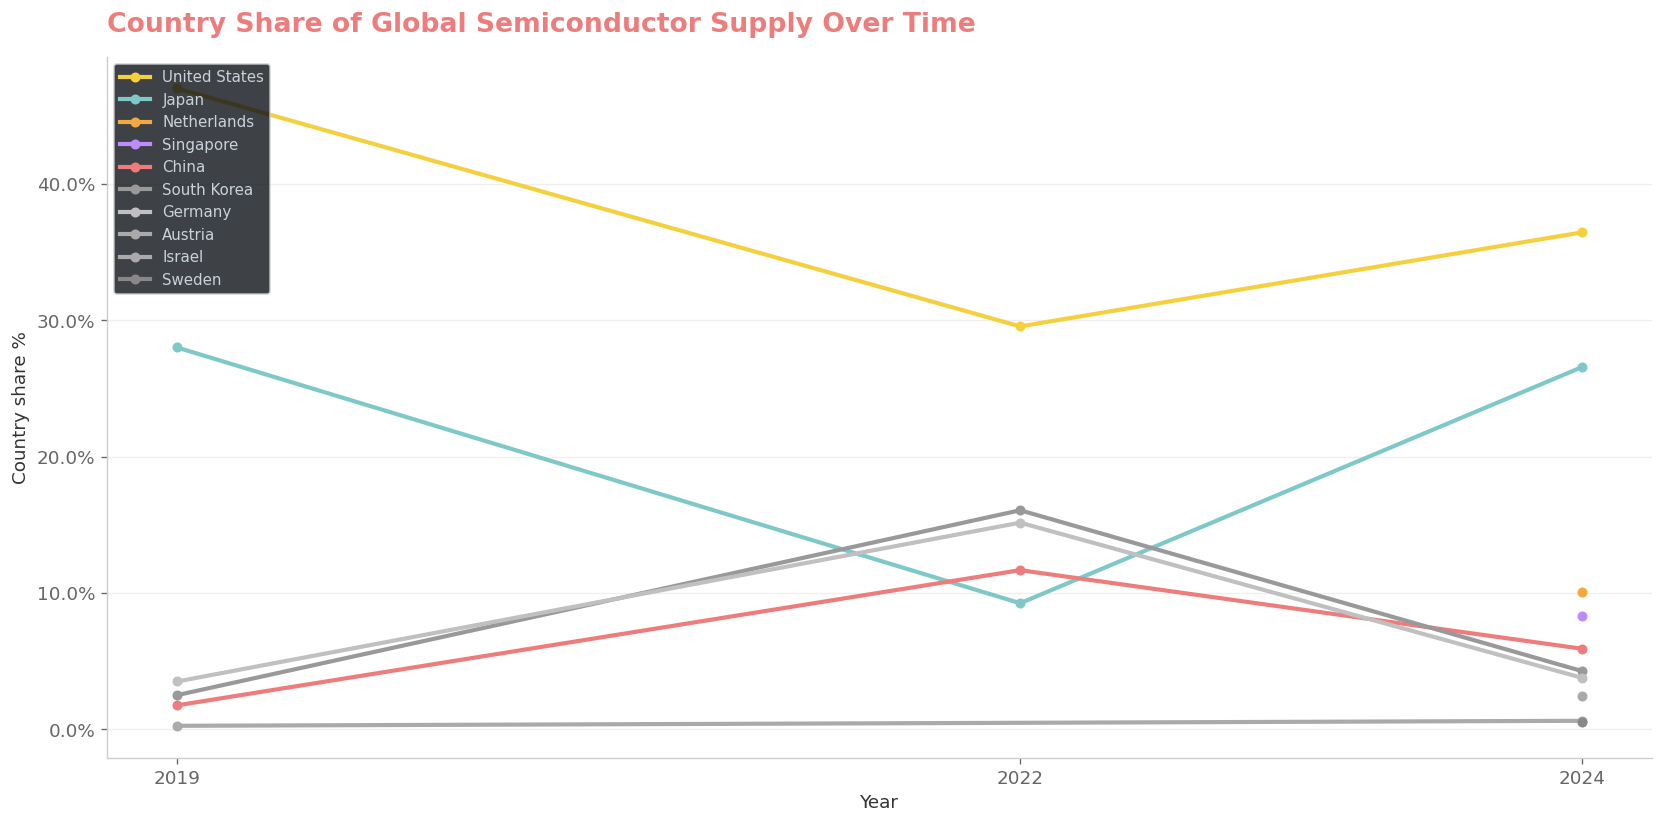

In [41]:
# Country share by year from provision data
semi_yearly = semi[
    (semi.provider_type == 'country') &
    (semi.share_provided.notna()) &
    (~semi.provider_name.str.contains('Various', case=False, na=False))
].copy()

semi_yearly['country_name'] = semi_yearly['provider_name'].map(ISO_TO_NAME).fillna(semi_yearly['provider_name'])

# Average share across all inputs per country per year
yearly_avg = semi_yearly.groupby(['country_name', 'provision_year']).agg(
    avg_share=('share_provided', 'mean'),
    total_share=('share_provided', 'sum'),
).reset_index()

# Normalize: country's total share as % of global total per year
year_totals = yearly_avg.groupby('provision_year')['total_share'].sum().reset_index(name='year_total')
yearly_avg = yearly_avg.merge(year_totals, on='provision_year')
yearly_avg['country_pct'] = yearly_avg['total_share'] / yearly_avg['year_total']

# Top countries by 2024 share
top_countries = yearly_avg[yearly_avg.provision_year == 2024].nlargest(10, 'country_pct')['country_name'].tolist()

country_line_colors = {
    'United States': '#F4D03F', 'Japan': '#7EC8C8', 'China': '#ED7D7D',
    'South Korea': '#999', 'Netherlands': '#F4A940', 'Taiwan': '#70AD47',
    'Germany': '#C0C0C0', 'Singapore': '#BC8CFF', 'United Kingdom': '#5B9BD5',
    'France': '#ED7D7D', 'Austria': '#AAA', 'Israel': '#AAA',
}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for country in top_countries:
    cdata = yearly_avg[yearly_avg.country_name == country].sort_values('provision_year')
    color = country_line_colors.get(country, '#888')
    ax.plot(cdata['provision_year'], cdata['country_pct'],
            color=color, linewidth=2.5, marker='o', markersize=5, label=country)

ax.set_title('Country Share of Global Semiconductor Supply Over Time',
             fontsize=16, fontweight='bold', color='#ED7D7D', loc='left', pad=15)
ax.set_xlabel('Year', fontsize=11, color='#333')
ax.set_ylabel('Country share %', fontsize=11, color='#333')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1%}' if v < 1 else f'{v:.0%}'))

ax.legend(loc='upper left', fontsize=9, frameon=True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
ax.tick_params(colors='#666')
ax.grid(axis='y', alpha=0.3, color='#ccc')

# Year filter annotation
years = sorted(yearly_avg.provision_year.unique())
ax.set_xticks(years)

plt.tight_layout()
plt.savefig('viz_semi_05_country_share_time.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 7. Summary Statistics for AISI Pipeline

Key metrics extracted for the Hardware Sovereignty dimension:

In [35]:
# ── AISI-relevant summary ──
country_only = master[
    (master['provider_type'] == 'country') & 
    (master['share_provided'].notna()) &
    (~master['provider_name'].str.contains('Various', case=False, na=False))
].copy()

total_inputs = master['input_id'].nunique()

aisi_summary = country_only.groupby('provider_name').agg(
    avg_market_share=('share_provided', 'mean'),
    peak_market_share=('share_provided', 'max'),
    inputs_with_presence=('input_id', 'nunique'),
).reset_index()

aisi_summary['supply_chain_breadth'] = aisi_summary['inputs_with_presence'] / total_inputs
aisi_summary['country'] = aisi_summary['provider_name'].map(iso_names).fillna(aisi_summary['provider_name'])
aisi_summary = aisi_summary.sort_values('avg_market_share', ascending=False)

print('AISI Hardware Sovereignty — Country Metrics Preview')
print('=' * 80)
display_cols = ['country', 'avg_market_share', 'peak_market_share', 
                'inputs_with_presence', 'supply_chain_breadth']
print(aisi_summary[display_cols].to_string(index=False, float_format='%.2f'))
print(f'\nTotal unique inputs in dataset: {total_inputs}')

AISI Hardware Sovereignty — Country Metrics Preview
       country  avg_market_share  peak_market_share  inputs_with_presence  supply_chain_breadth
 United States             44.52             100.00                    76                  0.67
     Singapore             35.87              97.80                    19                  0.17
   Netherlands             30.77             100.00                    27                  0.24
         Japan             30.65              99.60                    77                  0.68
       Austria             25.05              87.50                     8                  0.07
       Germany             14.63             100.00                    29                  0.25
        Sweden             11.60              37.30                     4                  0.04
           EUR              9.40              17.00                     5                  0.04
         China              9.19              68.70                    62           

---
## Done ✓

**Outputs saved:**
- `semiconductor_master.csv` — Combined & cleaned master dataset
- `semiconductor_sequence.csv` — Relationship graph (kept separate)
- 10 visualization PNGs

**Key findings:**
1. The supply chain is **tool-dominated** (90 of 126 inputs are tools)
2. **Extreme concentration** — most inputs have HHI > 2500 (highly concentrated)
3. **Japan and the US** have the broadest supply chain presence, while specific countries dominate chokepoints
4. The master dataset is ready for the AISI Hardware Sovereignty dimension calculation

**Next:** Country AI Activity Metrics dataset (publications, patents, investment)